<a href="https://colab.research.google.com/github/zuvelatamara/PPPO-2025/blob/main/PPPO_V7_Case_study_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Importujemo funkciju clear_output iz IPython biblioteke
# Ona omogućava brisanje prethodnog ispisa u Jupyter/Colab notebook-u
from IPython.display import clear_output

# Definišemo pomoćnu funkciju clear()
# Ova funkcija se koristi samo za "čišćenje" ekrana u notebook-u
# NEMA veze sa treniranjem modela ili deep learning-om
def clear():
    # Više puta brišemo prethodni output
    # (nekad se koristi da se izbegne treperenje prikaza u Colab-u)
    for i in range(10):
        clear_output(wait=True)
        print()  # ispisujemo prazan red radi boljeg vizuelnog efekta

# Importujemo Image i display funkcije
# One služe za prikaz slika direktno u notebook-u
from IPython.display import Image, display

## Sadržaj

1. Uvod  
2. Terminologija  
3. Opis podataka  
4. Metodologija treniranja  
5. Obučavanje klasifikacionih modela  
6. Zaključak  
7. Literatura  


### **Uvod**

Klasifikacija fotografija predstavlja nadgledani zadatak mašinskog učenja koji podrazumeva dodeljivanje najverovatnije oznake (klase) ulaznoj fotografiji iz unapred definisanog skupa kategorija. Drugim rečima, radi se o procesu dodeljivanja oznake fotografiji na osnovu njenog vizuelnog sadržaja.

U zavisnosti od broja i načina dodeljivanja klasa, razlikuju se četiri osnovne vrste klasifikacije:

- **Binary classification** – zadaci klasifikacije kod kojih postoje dve moguće klase  
- **Multi-class classification** – zadaci klasifikacije kod kojih postoji više klasa, pri čemu se svakoj instanci dodeljuje tačno jedna klasa  
- **Multi-label classification** – zadaci klasifikacije kod kojih instanca može pripadati jednoj ili više klasa istovremeno  
- **Imbalanced classification** – klasifikacioni zadaci kod kojih je broj instanci po klasama neravnomerno raspoređen

U ovom radu razmatra se problem klasifikacije biljaka na osnovu slike njihovog lista. Svaka instanca pripada jednoj od 99 mogućih klasa, zbog čega se problem može okarakterisati kao **multi-class klasifikacija**.

Prethodna istraživanja u oblasti prepoznavanja biljaka dovela su do razvoja različitih metoda analize listova. Botaničari u morfološkim i taksonomskim istraživanjima koriste različite karakteristike listova, među kojima se izdvajaju
- dvodimenzionalni oblik obrisa lista,
- struktura mreže vena,
-  kao i karakteristike ivica lista.

U skladu sa tim, automatski sistemi za klasifikaciju biljaka oslanjaju se na tehnike obrade slike koje se baziraju upravo na ovim vizuelnim karakteristikama.

Brojna istraživanja ukazuju na to da obris lista predstavlja jednu od najefektivnijih karakteristika za prepoznavanje biljnih vrsta, s obzirom na to da većina biljaka poseduje specifičan i lako uočljiv oblik lista [1].


###**Terminologija**

*Taksonomija* - naučna disciplina koja proučava principe, metode i svrhe klasifikacije. U biologiji se odnosi na uređenu i hijerarhijsku klasifikaciju živih bića.

*Margina* - ivuca, odnosno granična površina lista. Margine mogu biti glatke, zglobljene (nazubljene), lobanje ili razdvojene.

*Vene* - vaskularni snopovi, odnosno tkivni paketi koji obezbeđuju mehaničku podršku listu i omogućavaju transport vode i hranljivih materija.

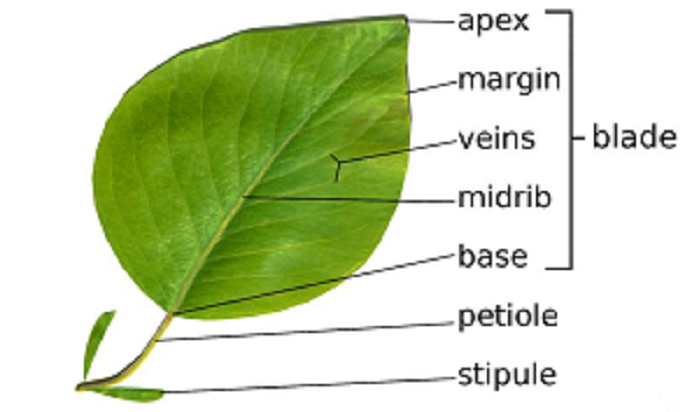

In [ ]:
display(Image('slike/list_terminologija.png'))

### **Opis podataka**

Skup podataka koji se koristi u ovom radu sastoji se od ukupno **1584 slike listova biljaka**, pri čemu svaka od **99 klasa (biljnih vrsta)** sadrži po **16 slika**. Svaka slika predstavlja jednu instancu u skupu podataka i pripada tačno jednoj klasi, zbog čega se problem klasifikacije može svrstati u **multi-class klasifikacione zadatke**.

Sve slike su **binarne**, sa belom pozadinom i crnim prikazom lista, pri čemu se razlikuju po rezoluciji. Takva reprezentacija omogućava lakšu analizu oblika lista i smanjuje uticaj šuma i varijacija u osvetljenju.

Pored samih slika, svaka instanca je dodatno opisana skupom unapred izračunatih karakteristika (*feature-a*), preuzetih iz relevantne literature [2].

Ovi feature-i obuhvataju:

- **deskriptore oblika lista**,  
- **histogram teksture**,  
- **histogram margine lista**.

Za svaki od navedenih feature-a formiran je vektor od **64 numerička atributa** za svaki od primeraka skupa podataka.


Preuzimanje dataset-a i csv fajlova:

In [ ]:
# Linkovi ka fajlovima koji se nalaze na Google Drive-u
# (ostavljeni su kao referenca – nisu neophodni za izvršavanje koda)
# https://drive.google.com/file/d/1Iaq6NNiR8CH4jruMs4wQoh-ZV5Nndm1f/view?usp=sharing
# https://drive.google.com/file/d/1q7Fy4SVLLODGQxzpZa3ZMOr0kBgKSRRh/view?usp=sharing
# https://drive.google.com/file/d/1ZyQ7jkw91kLyI8gnm_I9Cnlrm1qlQJPI/view?usp=sharing
# https://drive.google.com/file/d/1Egb1USY9s04hShkSHxTsRdtrFRTJK29f/view?usp=sharing

# Preuzimanje fajlova sa Google Drive-a pomoću alata gdown
# Svaki --id predstavlja jedinstveni identifikator fajla na Drive-u
!gdown --id "1Iaq6NNiR8CH4jruMs4wQoh-ZV5Nndm1f"
!gdown --id "1q7Fy4SVLLODGQxzpZa3ZMOr0kBgKSRRh"
!gdown --id "1ZyQ7jkw91kLyI8gnm_I9Cnlrm1qlQJPI"
!gdown --id "1Egb1USY9s04hShkSHxTsRdtrFRTJK29f"

# Raspakivanje (unzip) arhiva koje sadrže slike
# Nakon ove komande, slike postaju dostupne za dalju obradu
!unzip slike.zip
!unzip images.zip

# Čišćenje izlaza u notebook-u radi preglednijeg prikaza
# Ova funkcija je ranije definisana (Prvi blok) i nema uticaja na obradu podataka ili model
clear()


In [ ]:
#importing mpl models
#U ovoj ćeliji se preuzimaju unapred obučeni modeli neuronskih mreža.
#Ovakav pristup omogućava ponovno korišćenje modela bez potrebe za ponovnim treniranjem, što je korisno za evaluaciju i demonstraciju rezultata.
#https://drive.google.com/file/d/1_8y7wa-HkOO5HR_qlcfk_X4G76TrcvEs/view?usp=sharing
!gdown --id "1_8y7wa-HkOO5HR_qlcfk_X4G76TrcvEs"
!unzip nn_models.zip

Downloading...
From: https://drive.google.com/uc?id=1_8y7wa-HkOO5HR_qlcfk_X4G76TrcvEs
To: /content/nn_models.zip
43.9MB [00:02, 20.2MB/s]
Archive:  nn_models.zip
   creating: nn_models/
  inflating: nn_models/nn_model.hdf5  
  inflating: nn_models/nn_modelv2.hdf5  
  inflating: nn_models/nn_modelv3.hdf5  


U narednoj ćeliji vizualizujemo nasumično izabrane slike iz skupa podataka kako bismo stekli uvid u njihov izgled i kvalitet.
Prikaz više slika odjednom omogućava proveru da li su podaci pravilno učitani i da li su slike konzistentne u pogledu sadržaja i formata.
Ovaj korak je važan deo analize podataka pre treniranja modela.

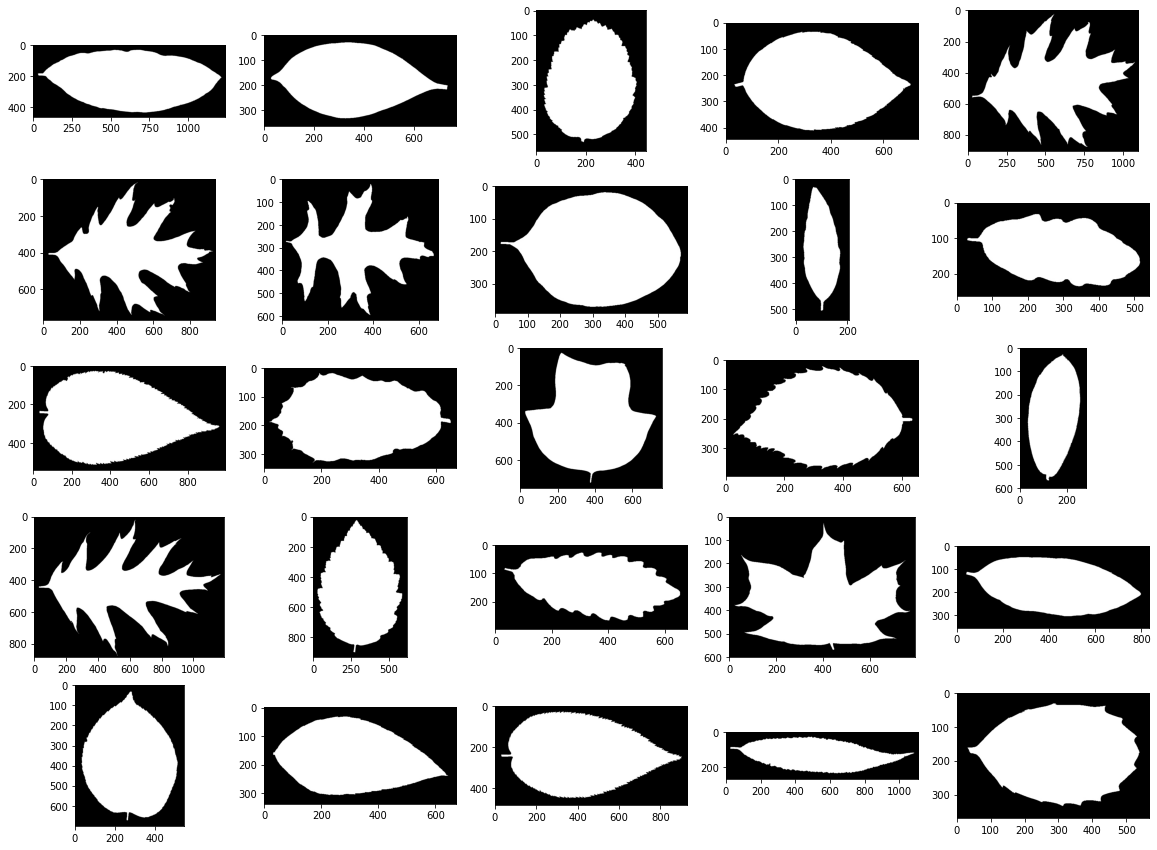

In [ ]:
# Import biblioteke matplotlib za prikaz slika
import matplotlib.pyplot as plt

# Import funkcije randrange za nasumičan izbor indeksa slike
from random import randrange

# Definisanje veličine figure za prikaz više slika odjednom
plt.figure(figsize=(20, 15))

# Import funkcije za učitavanje slike iz Keras biblioteke
from keras.preprocessing.image import load_img

# Prikaz 25 nasumično izabranih slika iz skupa podataka
for i in range(25):
    # Nasumično biramo indeks slike iz skupa od 1584 slike
    image_number = randrange(1584)

    # Definišemo poziciju slike u mreži 5x5
    plt.subplot(5, 5, i + 1)

    # Učitavanje slike sa diska
    img = load_img("/content/images/" + str(image_number) + ".jpg")

    # Prikaz slike
    plt.imshow(img)
    plt.axis("off")  # uklanjamo ose radi čistijeg prikaza


Fajl **train.csv** sadrži **990 zapisa** (labeliranih instanci) koji će se koristiti za treniranje klasifikacionog modela.

#### Polja u fajlu

- **id** – jedinstveni identifikator slike  
- **species** – naziv klase (vrste biljke) kojoj pripada instanca sa odgovarajućim *id*-em  

Pored identifikatora i labele, svaka instanca je opisana numeričkim atributima koji predstavljaju unapred izračunate *feature-e* (karakteristike) lista:

- **margin_1, margin_2, …, margin_64** – 64 atributa koji opisuju **marginu (ivicu) lista**  
- **shape_1, shape_2, …, shape_64** – 64 atributa koji opisuju **oblik lista**  
- **texture_1, texture_2, …, texture_64** – 64 atributa koji opisuju **teksturu lista**  

Ukupno, svaki primer je predstavljen ulaznim vektorom od **192 numerička atributa** (3 × 64).


U narednoj ćeliji se učitavaju trening i test podaci iz CSV fajlova.
Prikaz prvih nekoliko redova omogućava proveru da li su podaci pravilno učitani, dok funkcija describe() daje osnovni statistički uvid u numeričke atribute.

In [ ]:
# Import biblioteke pandas za rad sa tabelarnim podacima
import pandas as pd

# Učitavanje trening i test skupa iz CSV fajlova
# index_col=False znači da se nijedna kolona ne koristi kao indeks DataFrame-a
df_train = pd.read_csv('/content/train.csv', index_col=False)
df_test = pd.read_csv('/content/test.csv', index_col=False)

# Prikaz prvih nekoliko redova test skupa
# Ovaj korak služi za brzu proveru strukture podataka
print(df_test.head())

# Prikaz osnovnih statističkih mera za numeričke kolone u test skupu
# (srednja vrednost, standardna devijacija, minimum, maksimum, itd.)
print(df_test.describe())


   id   margin1   margin2   margin3  ...  texture61  texture62  texture63  texture64
0   4  0.019531  0.009766  0.078125  ...        0.0   0.000000   0.003906   0.053711
1   7  0.007812  0.005859  0.064453  ...        0.0   0.000977   0.037109   0.044922
2   9  0.000000  0.000000  0.001953  ...        0.0   0.015625   0.000000   0.000000
3  12  0.000000  0.000000  0.009766  ...        0.0   0.089844   0.000000   0.008789
4  13  0.001953  0.000000  0.015625  ...        0.0   0.007812   0.009766   0.007812

[5 rows x 193 columns]
                id     margin1     margin2  ...   texture62   texture63   texture64
count   594.000000  594.000000  594.000000  ...  594.000000  594.000000  594.000000
mean    780.673401    0.017562    0.028425  ...    0.019975    0.009389    0.020970
std     465.646977    0.019585    0.038351  ...    0.034704    0.013457    0.023407
min       4.000000    0.000000    0.000000  ...    0.000000    0.000000    0.000000
25%     368.500000    0.001953    0.001953  ..

Prikaz prvih nekoliko redova test skupa (`head()`) pokazuje da se svaki zapis sastoji od **193 kolone**. Prva kolona predstavlja jedinstveni identifikator slike (*id*), dok preostalih **192 kolone** odgovaraju numeričkim feature-ima koji opisuju karakteristike lista (margina, oblik i tekstura).

Rezultati funkcije `describe()` pružaju osnovni statistički uvid u numeričke atribute test skupa. Za svaku kolonu prikazane su vrednosti kao što su broj instanci (*count*), srednja vrednost (*mean*), standardna devijacija (*std*), minimalna (*min*), maksimalna (*max*) i kvartilne vrednosti (*25%*, *50%*, *75%*).

Na osnovu prikazanih statistika može se uočiti da su vrednosti feature-a **normalizovane i ograničene na mali opseg**, najčešće između 0 i 1, što je pogodno za treniranje neuronskih mreža. Takođe, svi numerički atributi su kontinuirani, bez očiglednih ekstremnih vrednosti koje bi mogle negativno uticati na proces učenja modela.


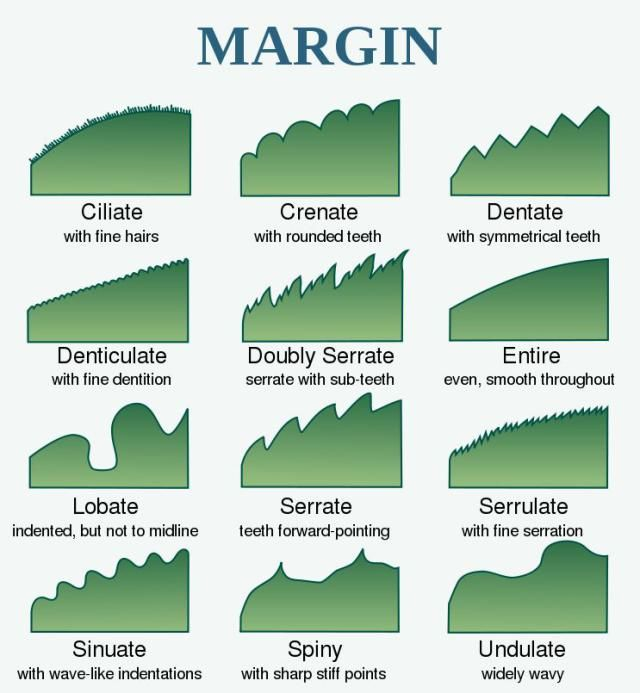

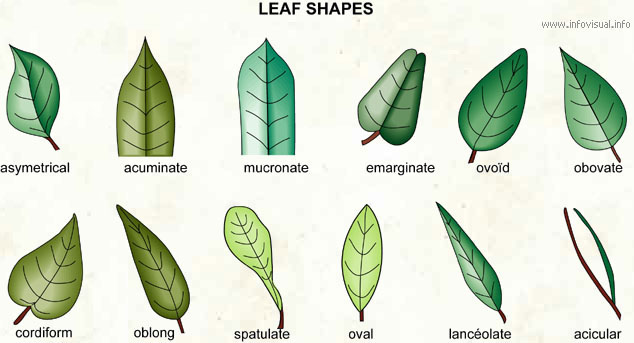

Prikazane slike ilustruju morfološke karakteristike listova koje se koriste u procesu klasifikacije biljaka. Poseban značaj imaju **margina lista** i **oblik lista**, jer predstavljaju vizuelno prepoznatljive i diskriminativne osobine između različitih biljnih vrsta.

Margina lista opisuje izgled ivice lista i može imati različite forme, kao što su glatka (entire), nazubljena (dentate), testerasta (serrate), talasasta (undulate) ili režnjevita (lobate). Ove razlike direktno utiču na vrednosti feature-a koji opisuju marginu lista i omogućavaju modelu da razlikuje vrste biljaka sa sličnim opštim oblikom, ali različitim ivicama lista.

Oblik lista predstavlja celokupan obris lista i uključuje forme poput ovalnog (oval), jajolikog (ovoid), kopljastog (lanceolate), duguljastog (oblong) ili srcastog (cordiform) oblika. Ove morfološke razlike se kvantifikuju kroz deskriptore oblika i predstavljaju važan izvor informacija za klasifikacioni model.

Kombinovanjem informacija o **margini**, **obliku** i **teksturi** lista formira se bogata numerička reprezentacija svake instance, što omogućava neuronskoj mreži da efikasno uči razlike između 99 biljnih vrsta.


---------------------------------------------------------------------

Prikaz raspodele klasa pomoću funkcije `value_counts()` omogućava proveru izbalansiranosti trening skupa. Na osnovu rezultata može se uočiti da svaka klasa sadrži isti broj instanci, što ukazuje na **balansiran skup podataka** i smanjuje rizik od pristrasnosti modela prema pojedinim klasama.

Dodatno, proverom nedostajućih vrednosti pomoću funkcije `isnull().sum()` potvrđeno je da u trening skupu **ne postoje nedostajuće vrednosti**. Time je obezbeđeno da nije neophodna dodatna imputacija podataka pre treniranja neuronske mreže.


In [ ]:
# Prikaz broja instanci po svakoj klasi (vrsti biljke)
# Ovim proveravamo da li su klase ravnomerno zastupljene
print(df_train["species"].value_counts())

# Provera da li u skupu podataka postoje nedostajuće vrednosti (NaN)
# Za svaku kolonu se ispisuje broj nedostajućih vrednosti
print(df_train.isnull().sum())

Alnus_Maximowiczii        10
Populus_Nigra             10
Quercus_Phillyraeoides    10
Quercus_Chrysolepis       10
Quercus_Ilex              10
                          ..
Phildelphus               10
Sorbus_Aria               10
Prunus_Avium              10
Cornus_Controversa        10
Tilia_Tomentosa           10
Name: species, Length: 99, dtype: int64
id           0
species      0
margin1      0
margin2      0
margin3      0
            ..
texture60    0
texture61    0
texture62    0
texture63    0
texture64    0
Length: 194, dtype: int64


Rezultati analize raspodele klasa pokazuju da se u trening skupu nalazi **99 različitih biljnih vrsta**, pri čemu svaka klasa sadrži **tačno 10 instanci**. Na osnovu toga može se zaključiti da je trening skup **potpuno izbalansiran**, što je povoljno za treniranje klasifikacionih modela i smanjuje rizik od pristrasnosti prema pojedinim klasama.

Provera nedostajućih vrednosti pokazuje da u skupu podataka **ne postoje NaN vrednosti** ni u jednoj od 194 kolone (uključujući identifikator, labelu i sve feature-e). Zbog toga nije neophodna dodatna imputacija podataka pre faze treniranja modela.


### **Mogući pristupi**

Za treniranje klasifikacionih modela mogu se koristiti unapred ekstraktovani *feature-i*, same slike ili kombinacija ova dva tipa podataka.

Pored već dostupnih ekstraktovanih feature-a, moguće je izvršiti i dodatnu ekstrakciju karakteristika. Ovi dodatni feature-i mogu biti ručno definisani ili dobijeni primenom postojećih algoritama, pri čemu je neophodno razmotriti metode koje imaju smisla primenjivati na binarnim slikama. Primeri takvih feature-a uključuju:

- **HuMoments** – kvantifikuju oblik objekta na slici i često se koriste za opisivanje kontura,  
- **odnos crnih i belih piksela**,  
- **rezoluciju slike**,  
- **odnos širine i visine slike**,  
- **orijentaciju slike - Horizontalna/Vertikalna** (npr. da li je širina veća od visine).

Alternativno, ulazni podaci modela mogu biti i same slike. U tom slučaju se za klasifikaciju koriste modeli **dubokog učenja**, najčešće **konvolucione neuronske mreže (CNN)**. CNN arhitekture sadrže konvolucione slojeve koji automatski uče relevantne feature-e direktno iz ulaznih slika.

Međutim, neuronske mreže koje u svojoj arhitekturi sadrže **fully connected slojeve** zahtevaju ulazne slike fiksne veličine. S obzirom na to da slike u korišćenom skupu podataka imaju varijabilne rezolucije, primena ovakvih arhitektura bi zahtevala dodatne tehnike pretprocesiranja, kao što su skaliranje ili promene rezolucije slika. Kao alternativa, moguće je koristiti **fully convolutional arhitekture**, koje omogućavaju rad sa slikama varijabilne veličine.

Kod modela dubokog učenja potrebno je uzeti u obzir i količinu raspoloživih podataka za treniranje. Previše kompleksni modeli mogu biti teški za obučavanje i skloni pojavi **overfitting-a**, naročito kada je skup podataka ograničen. U cilju povećanja efektivne veličine skupa podataka, često se primenjuju tehnike **augmentacije podataka**, kojima se iz originalnih slika generišu nove varijante (npr. rotacije, promene orijentacije ili skaliranje).

Zbog činjenice da unapred ekstraktovani feature-i predstavljaju **najrelevantnije karakteristike za prepoznavanje biljnih vrsta** [2], u ovom radu nije vršena dodatna ekstrakcija feature-a niti treniranje konvolucionih neuronskih mreža. Umesto toga, klasifikacioni modeli su obučavani isključivo na osnovu ovih numeričkih karakteristika.


### **Pretprocesuiranje podataka**

U korišćenom skupu podataka ne postoje nedostajuće vrednosti, niti disbalans klasa koji bi mogao negativno uticati na procenu tačnosti modela. Zbog toga nije bila potrebna dodatna imputacija podataka niti primena tehnika za balansiranje klasa.

Svi feature-i u skupu podataka predstavljaju numeričke atribute. Jedini korak pretprocesuiranja odnosi se na transformaciju ciljne promenljive (*labela*), koja je u početnom obliku kategorička. Kodiranje labela u numerički oblik izvršeno je primenom **LabelEncoder** klase, čime su omogućeni ulazni podaci odgovarajućeg formata za treniranje neuronske mreže.


In [ ]:
# Import LabelEncoder klase za kodiranje kategoričkih labela u numerički oblik
from sklearn.preprocessing import LabelEncoder

# Import numpy biblioteke za rad sa nizovima
import numpy as np

# Inicijalizacija LabelEncoder objekta
encoder = LabelEncoder()

# Učenje mapiranja između naziva klasa i numeričkih vrednosti
le = encoder.fit(df_train.species)
# Transformacija tekstualnih labela (naziva vrsta) u numeričke vrednosti
labels = le.transform(df_train.species)
# Pravimo kopiju labela (npr. za kasniju upotrebu ili poređenje)
labels_copy = labels.copy()
# Lista svih klasa u redosledu koji odgovara numeričkom kodiranju
classes = list(le.classes_)
print(classes)

# Prikaz svih jedinstvenih numeričkih labela
uniquelabels = np.unique(labels)
print(uniquelabels)


['Acer_Capillipes', 'Acer_Circinatum', 'Acer_Mono', 'Acer_Opalus', 'Acer_Palmatum', 'Acer_Pictum', 'Acer_Platanoids', 'Acer_Rubrum', 'Acer_Rufinerve', 'Acer_Saccharinum', 'Alnus_Cordata', 'Alnus_Maximowiczii', 'Alnus_Rubra', 'Alnus_Sieboldiana', 'Alnus_Viridis', 'Arundinaria_Simonii', 'Betula_Austrosinensis', 'Betula_Pendula', 'Callicarpa_Bodinieri', 'Castanea_Sativa', 'Celtis_Koraiensis', 'Cercis_Siliquastrum', 'Cornus_Chinensis', 'Cornus_Controversa', 'Cornus_Macrophylla', 'Cotinus_Coggygria', 'Crataegus_Monogyna', 'Cytisus_Battandieri', 'Eucalyptus_Glaucescens', 'Eucalyptus_Neglecta', 'Eucalyptus_Urnigera', 'Fagus_Sylvatica', 'Ginkgo_Biloba', 'Ilex_Aquifolium', 'Ilex_Cornuta', 'Liquidambar_Styraciflua', 'Liriodendron_Tulipifera', 'Lithocarpus_Cleistocarpus', 'Lithocarpus_Edulis', 'Magnolia_Heptapeta', 'Magnolia_Salicifolia', 'Morus_Nigra', 'Olea_Europaea', 'Phildelphus', 'Populus_Adenopoda', 'Populus_Grandidentata', 'Populus_Nigra', 'Prunus_Avium', 'Prunus_X_Shmittii', 'Pterocarya_S

In [ ]:
# Iz trening skupa uklanjamo kolone koje se ne koriste kao ulaz u model:
# - 'id' je identifikator i nema informativnu vrednost za klasifikaciju
# - 'species' je ciljna promenljiva (labela) i ne sme biti deo ulaza
df_train = df_train.drop(['id', 'species'], axis=1)

# Čuvamo identifikatore test instanci radi kasnije upotrebe (npr. za predikcije)
test_id = df_test.id

# Iz test skupa uklanjamo kolonu 'id', jer model očekuje samo numeričke feature-e
df_test = df_test.drop(['id'], axis=1)

# Prikaz informacija o trening skupu (broj redova, kolona i tipovi podataka)
print(df_train.info())
# Prikaz informacija o test skupu
print(df_test.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 990 entries, 0 to 989
Columns: 192 entries, margin1 to texture64
dtypes: float64(192)
memory usage: 1.5 MB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594 entries, 0 to 593
Columns: 192 entries, margin1 to texture64
dtypes: float64(192)
memory usage: 891.1 KB
None


Izvršeno je skaliranje feature-a podataka. Skaliranje podataka predstavlja postupak standardizacije ili normalizacije, kojim se vrednosti atributa dovode u uporediv opseg. Ovaj korak može značajno ubrzati proces učenja prilikom primene algoritama zasnovanih na **stohastičkom gradijentnom spustu**, jer omogućava stabilnije i efikasnije ažuriranje težina modela.

Skaliranje pomaže modelu da uči brže i stabilnije, naročito kada se koriste neuronske mreže i algoritmi zasnovani na gradijentnom spustu.

Skaliranje je naročito važno kod algoritama koji se oslanjaju na računanje distance između instanci u skupu podataka. U takvim slučajevima, feature-i sa većim numeričkim opsegom mogu imati disproporcionalno veći uticaj na izračunavanje distance, čak i kada su razlike u vrednostima feature-a manjeg opsega informativno značajnije u okviru sopstvenog opsega.

Sa druge strane, pojedini algoritmi, kao što su **Naive Bayes** i **Linear Discriminant Analysis (LDA)**, dizajnirani su tako da implicitno uzimaju u obzir različite opsege atributa, dodeljujući težine karakteristikama u skladu sa njihovim statističkim svojstvima. Zbog toga kod ovih algoritama skaliranje podataka nije uvek neophodno.


In [ ]:
# Import StandardScaler za standardizaciju podataka
from sklearn.preprocessing import StandardScaler

# Inicijalizacija skalera
sc = StandardScaler()

# Skaliranje trening skupa:
# - fit: uči parametre (mean, std) ISKLJUČIVO na trening podacima
# - transform: primenjuje standardizaciju
X_train_scaled = sc.fit_transform(df_train)

# Skaliranje test skupa koristeći ISTE parametre naučene na trening skupu
X_test_scaled = sc.transform(df_test)

# (Opcionalno) čuvamo kopije originalnih podataka
df_train_copy = df_train.copy()
df_test_copy = df_test.copy()


###**Metodologija treniranja**

### **Metodologija treniranja**

#### **Unakrsna validacija**

Algoritmi klasifikacije se treniraju korišćenjem primera iz trening skupa podataka, dok se njihove performanse procenjuju na podacima koji nisu korišćeni tokom procesa učenja. Na ovaj način se dobija realnija procena sposobnosti modela da generalizuje na nove, neviđene podatke.

Za procenu performansi korišćen je trening skup podataka, nad kojim je primenjena tehnika **unakrsne validacije** (*cross-validation*). Ova tehnika podrazumeva podelu trening skupa na **𝑘 podskupova** (fold-ova) približno iste veličine. U svakom koraku, **𝑘 − 1 podskupova** koristi se za treniranje modela, dok se preostali podskup koristi kao validacioni skup.

Postupak se ponavlja **𝑘 puta**, pri čemu svaki podskup tačno jednom ima ulogu validacionog skupa. Konačna procena performansi modela dobija se agregacijom rezultata iz svih iteracija, čime se smanjuje zavisnost evaluacije od konkretne podele podataka.


##### **Stratifikacija**

Zbog velikog broja klasa i malog broja instanci po klasi, neophodno je obezbediti da raspodela klasa u svakom delu tokom postupka unakrsne validacije bude što sličnija raspodeli u originalnom trening skupu podataka. U suprotnom, pojedini podskupovi mogli bi ostati bez predstavnika određenih klasa, što bi dovelo do nepouzdane procene performansi modela.

Kako bi se očuvala približno ista distribucija klasa u svakom od 𝑘 delova, postupak podele podataka se modifikuje primenom **stratifikacije**. Stratifikacija obezbeđuje da svaka klasa bude podjednako zastupljena u svim fold-ovima, u skladu sa zastupljenošću u inicijalnom skupu podataka [3].

U praksi se za parametar 𝑘 najčešće biraju vrednosti **5** ili **10**. S obzirom na relativno malu veličinu skupa podataka koji se koristi u ovom radu, izabrana je vrednost **𝑘 = 5**, čime se postiže balans između pouzdanosti evaluacije i računske efikasnosti.


**Sumarno:** Stratifikacija obezbeđuje da svaka klasa bude prisutna u svakom delu podataka tokom validacije, što je posebno važno kada ima mnogo klasa sa malo primera, što je naš slučaj.

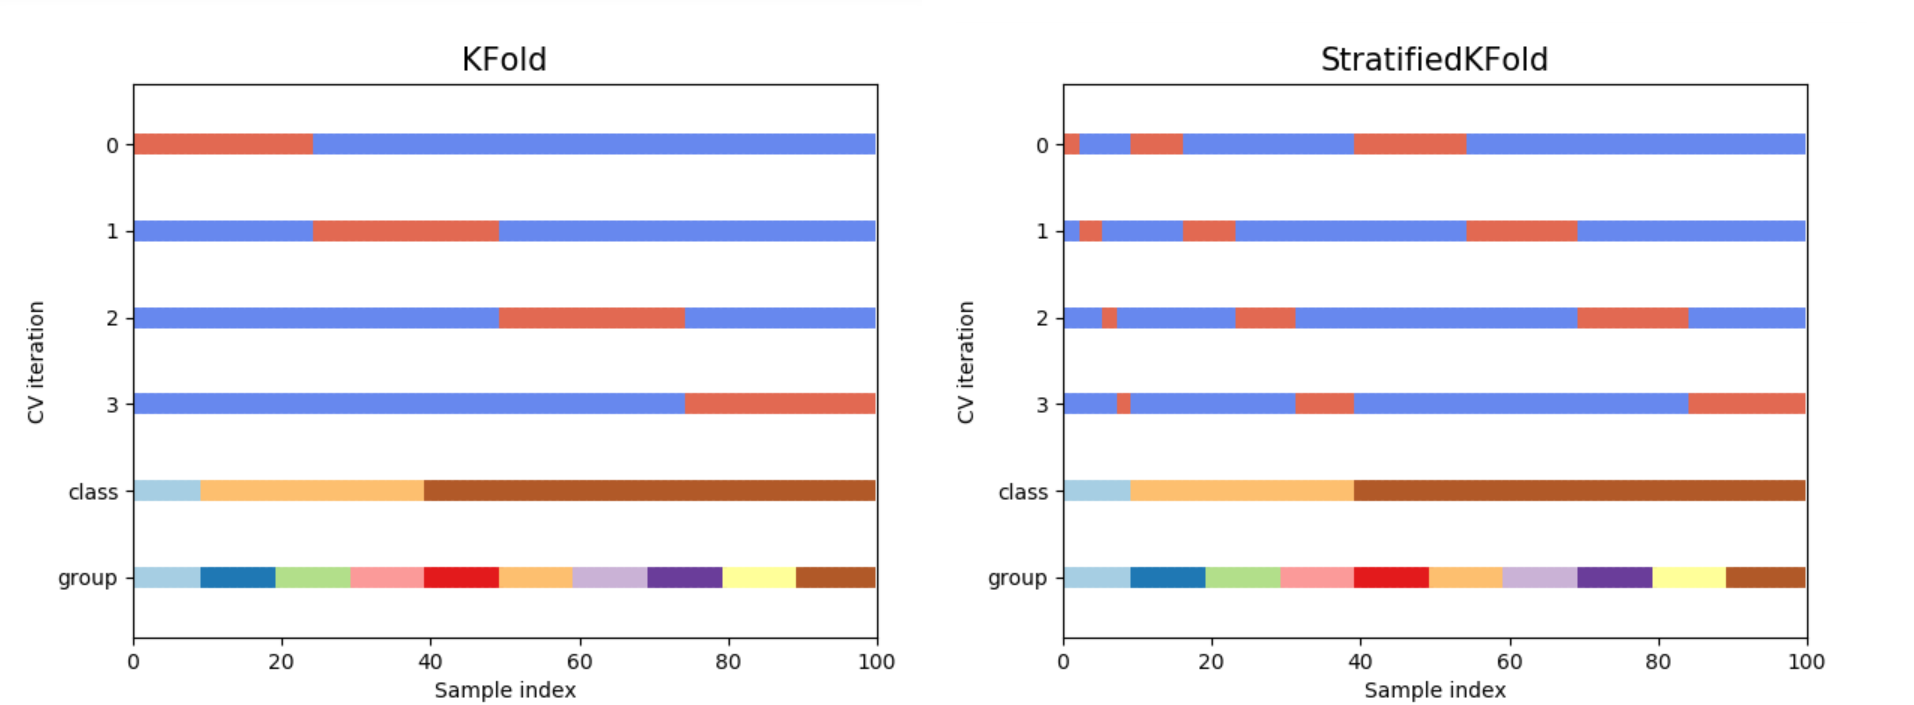

Prikazana slika ilustruje razliku između standardne **K-Fold unakrsne validacije** i **Stratified K-Fold unakrsne validacije**. Kod klasične K-Fold metode, podaci se dele na podskupove bez uzimanja u obzir raspodele klasa, što može dovesti do situacije da pojedini fold-ovi sadrže neravnomernu zastupljenost klasa ili čak da neke klase budu u potpunosti izostavljene iz validacionog skupa.

Sa druge strane, **Stratified K-Fold** metoda obezbeđuje da raspodela klasa u svakom fold-u bude približno ista kao u originalnom skupu podataka. Na taj način se garantuje da su sve klase ravnomerno zastupljene tokom svakog koraka unakrsne validacije, čime se dobija pouzdanija i realnija procena performansi modela.

Ovakav pristup je posebno važan u problemima sa **velikim brojem klasa i malim brojem instanci po klasi**, kao što je slučaj u ovom radu (99 klasa sa po 10 instanci). Zbog toga je u ovom istraživanju primenjena **Stratified K-Fold unakrsna validacija sa 𝑘 = 5**.


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold

# Funkcija koja radi Stratified K-Fold evaluaciju za prosleđeni klasifikator
# classifier treba da ima sklearn-like interfejs: .fit(X, y) i .score(X, y)
# df_train ovde predstavlja feature matrica (192 numerička atributa)
def stratified_k_fold(classifier, df_train):

    # Inicijalizacija StratifiedKFold:
    # - n_splits=5: koristi se 5 fold-ova (k=5)
    # - shuffle=True: mešanje podataka pre podele
    # - random_state=4: fiksira slučajnost radi reproduktivnosti rezultata
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=4)

    # Kreiramo DataFrame labela od globalne promenljive 'labels'
    # (labels je ranije dobijen LabelEncoder transformacijom kolone 'species')
    df_labels = pd.DataFrame(labels)

    # split() generiše indekse trening i validacionog dela za svaki fold,
    # uz očuvanje distribucije klasa (stratifikacija)
    splits = skf.split(df_train, df_labels)

    # Niz u koji upisujemo score iz svakog fold-a
    scores = np.array([])

    # Prolazimo kroz svih 5 podela (fold-ova)
    for n, (train_index, test_index) in enumerate(splits):

        # Izdvajamo trening i validacioni deo feature-a po indeksima
        X_train, X_test = df_train.iloc[train_index, :], df_train.iloc[test_index, :]

        # Izdvajamo trening i validacione labele po indeksima
        y_train, y_test = df_labels.iloc[train_index, :], df_labels.iloc[test_index, :]

        # Pretvaramo (n,1) u (n,) jer većina klasifikatora očekuje 1D niz
        y_test = np.ravel(y_test)
        y_train = np.ravel(y_train)

        # Treniramo klasifikator na trening delu i merimo score na validacionom delu.
        # .score() je najčešće accuracy kod sklearn klasifikatora.
        scores = np.append(
            scores,
            np.array([classifier.fit(X_train, y_train).score(X_test, y_test).mean()]),
            axis=None
        )

        # Ovaj blok je zakomentarisana diagnostika koja može pomoći
        # za proveru raspodele klasa po fold-u (nije obavezno za rad modela)
        # print(f'SPLIT NO {n+1}\nTRAINING SET SIZE: {np.round(len(train_index) / (len(train_index)+len(test_index)),2)}'+
        #         f'\tTEST SET SIZE: {np.round(len(test_index) / (len(train_index)+len(test_index)),2)}\nPROPORTION OF TARGET IN THE TRAINING SET\n'+
        #         f'{df_train.iloc[test_index,5].value_counts() / len(df_train.iloc[test_index,5])}\nPROPORTION OF TARGET IN THE TEST SET\n'+
        #         f'{df_train.iloc[train_index,5].value_counts() / len(df_train.iloc[train_index,5])}\n\n')

    # Vraćamo score za svaki fold (niz dužine 5)
    return scores

### **Obučavanje klasifikacionih modela**

#### **Vrste klasifikatora**

Za rešavanje zadatka multi-class klasifikacije biljnih vrsta razvijeno je ukupno **šest različitih klasifikacionih modela**. Cilj je bio uporediti performanse različitih algoritama mašinskog i dubokog učenja nad istim skupom podataka i istim postupkom evaluacije.

Korišćeni su sledeći klasifikatori:

- **SGD Classifier (Stochastic Gradient Descent)**  
- **Random Forest Classifier**  
- **KNeighbors Classifier**  
- **SVM Classifier (Support Vector Machine)**  
- **Naive Bayes Classifier**  
- **MLP (Multilayer Perceptron)**  

Ovi modeli obuhvataju različite paradigme učenja, uključujući linearne modele, metode zasnovane na udaljenosti, ansambl metode, probabilističke modele i neuronske mreže, čime se omogućava sveobuhvatna analiza njihovih performansi na datom problemu.


##### **Uspešnost klasifikacije**

Kao standardna mera uspešnosti klasifikacije korišćena je **tačnost klasifikacije** (*classification accuracy*). Tačnost klasifikacije definiše se kao odnos broja tačno klasifikovanih instanci i ukupnog broja instanci u test skupu, izražen u procentima.

Matematički, tačnost klasifikacije može se izraziti sledećom formulom:

**𝐴𝐶𝐶 = 𝑏𝑟𝑜𝑗 𝑡𝑎č𝑛𝑜 𝑘𝑙𝑎𝑠𝑖𝑓𝑖𝑘𝑜𝑣𝑎𝑛𝑖ℎ 𝑠𝑙𝑖𝑘𝑎/𝑢𝑘𝑢𝑝𝑎𝑛 𝑏𝑟𝑜𝑗 𝑠𝑙𝑖𝑘𝑎 𝑡𝑒𝑠𝑡 𝑠𝑘𝑢𝑝𝑎 × 100%**

Ova metrika pruža intuitivnu i lako razumljivu meru performansi klasifikacionog modela i posebno je pogodna za evaluaciju problema sa **izbalansiranim klasama**, kao što je slučaj u ovom radu.


##### **Bias–Variance tradeoff**

**Bias** predstavlja razliku između prosečne predikcije modela i stvarne vrednosti koju model pokušava da predvidi. Visok bias ukazuje na sistematsku grešku u učenju i znači da model nije uspeo da nauči bitne povezanosti između karakteristika podataka i ciljne promenljive.

**Variance** predstavlja varijabilnost predikcija modela u zavisnosti od različitih trening skupova. Visoka varijansa nastaje kada je model previše osetljiv na male promene u trening podacima, što dovodi do loše generalizacije na nove, neviđene podatke.

Model sa **visokim bias-om** pati od problema *underfitting-a*, jer je previše jednostavan da bi uhvatio složenost podataka. Sa druge strane, model sa **visokom varijansom** pati od problema *overfitting-a*, jer uči i šum prisutan u podacima, umesto opštih obrazaca.

Primena **unakrsne validacije sa 𝑘 fold-ova** omogućava procenu stabilnosti i pouzdanosti modela. Za svaki fold izračunava se tačnost klasifikacije, a ukupna tačnost modela predstavlja prosečnu vrednost tačnosti dobijene u svih 𝑘 iteracija. Na osnovu ovih vrednosti moguće je izračunati i **standardnu devijaciju**, koja predstavlja indikator varijanse modela. Visoka prosečna tačnost ukazuje na nizak bias, dok visoka standardna devijacija ukazuje na visoku varijansu.

Problem **bias–variance tradeoff-a** odnosi se na pronalaženje optimalnog balansa između ove dve vrste greške, kako bi se minimizovala ukupna greška modela i obezbedila dobra generalizacija na nove podatke [4].

Ukupna greška modela može se predstaviti sledećim izrazom:

***Total Error* = *Bias*^2 + *Variance* + *Irreducible Error***

**Zaključak: Previše jednostavan model greši jer ne uči dovoljno (bias), a previše složen jer uči šum (variance).
Cilj je pronaći model koji pravi najbolji kompromis između ova dva efekta. **


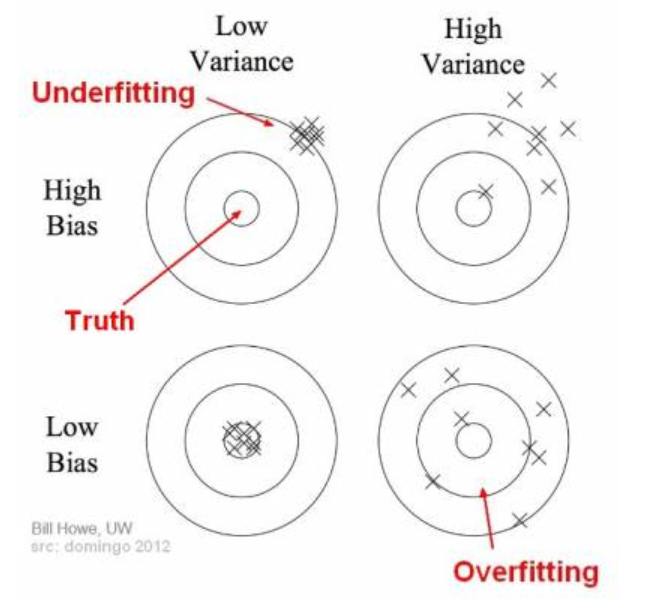

Prikazana slika ilustruje odnos između **bias-a** i **varijanse** modela kroz četiri karakteristična slučaja. Centar mete predstavlja stvarnu vrednost (*ground truth*), dok pojedinačni znakovi (predikcije) označavaju izlaze modela treniranog na različitim skupovima podataka.

U slučaju **visokog bias-a i niske varijanse**, predikcije su grupisane, ali udaljene od stvarne vrednosti. Ovakvo ponašanje odgovara problemu *underfitting-a*, gde model nije dovoljno složen da bi naučio relevantne obrasce u podacima.

Kod **niskog bias-a i visoke varijanse**, predikcije su rasute oko centra, što ukazuje na *overfitting*. U ovom slučaju model je previše osetljiv na promene u trening podacima i uči šum, što dovodi do slabe generalizacije.

Idealna situacija predstavlja kombinaciju **niskog bias-a i niske varijanse**, gde su predikcije koncentrisane oko stvarne vrednosti. Cilj procesa modelovanja jeste približavanje ovom balansu, čime se minimizuje ukupna greška modela i postiže dobra generalizacija na nove podatke.


In [ ]:
# Import metrika za evaluaciju klasifikacionih modela
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Funkcija za treniranje i evaluaciju klasifikacionog modela
def train_model(classifier, X_train, X_test, y_train, y_test):

    # Treniranje klasifikatora na trening skupu
    classifier.fit(X_train, y_train)
    # Predikcija klasa na test skupu
    y_pred = classifier.predict(X_test)
    # Izračunavanje tačnosti klasifikacije
    accuracy = accuracy_score(y_test, y_pred)
    # Izračunavanje konfuzione matrice
    cm = confusion_matrix(y_test, y_pred)

    # Ispis tačnosti
    print(accuracy)

    # Opcioni ispisi za detaljniju analizu performansi modela
    # print(cm)
    # print(classification_report(y_test, y_pred))

    # Funkcija vraća tačnost klasifikacije
    return accuracy

#### **SGD Classifier**

SGD klasifikator predstavlja **linearni model** koji se može koristiti za rešavanje različitih klasifikacionih problema, uključujući **logističku regresiju** i **linearni Support Vector Machine (SVM)**. Ovaj klasifikator koristi **stohastički gradijentni spust** (*Stochastic Gradient Descent*) kao metodu optimizacije tokom procesa treniranja.

Tokom treniranja, u svakom koraku se računa gradijent funkcije gubitka, nakon čega se parametri modela ažuriraju u smeru koji vodi ka minimizaciji ove funkcije. Ovakav pristup omogućava efikasno treniranje modela čak i na većim skupovima podataka.

##### **Stochastic Gradient Descent**

Stohastički gradijentni spust predstavlja **iterativnu metodu za optimizaciju funkcije greške** (*loss* ili *cost function*). Za razliku od klasičnog gradijentnog spusta, gde se gradijent računa na osnovu celokupnog skupa podataka, kod stohastičkog gradijentnog spusta gradijent se aproksimira korišćenjem **pojedinačnih primera ili manjih podskupova podataka**.

Zahvaljujući ovoj aproksimaciji, SGD omogućava brže ažuriranje parametara i manju računsku složenost po iteraciji, ali može dovesti do većih oscilacija tokom učenja. Uprkos tome, SGD se često koristi u praksi zbog svoje efikasnosti i skalabilnosti.


**Zaključak:** SGD klasifikator je brz linearni model koji uči tako što korak po korak ispravlja grešku na osnovu malog broja primera.

In [ ]:
# Import SGDClassifier-a (linearni klasifikator treniran SGD-om)
from sklearn.linear_model import SGDClassifier
# Inicijalizacija klasifikatora sa podrazumevanim parametrima
classifier = SGDClassifier()

# Evaluacija modela korišćenjem Stratified K-Fold unakrsne validacije
scores = stratified_k_fold(classifier, df_train)

# Ispis tačnosti po svakom fold-u
print(scores)

# Računanje prosečne tačnosti klasifikacije
sgd_acc = np.mean(scores, dtype=np.float64)
# Računanje standardne devijacije tačnosti (indikator varijanse)
sgd_std = np.std(scores, dtype=np.float64)

# Ispis prosečne tačnosti i standardne devijacije
print(sgd_acc)
print(sgd_std)

[0.71212121 0.52020202 0.64646465 0.67171717 0.60606061]
0.6313131313131313
0.06538404982901923


#### **Random Forest Classifier**

Random Forest (nasumična šuma) predstavlja algoritam nadgledanog učenja koji pripada grupi **ansambl metoda**, a zasniva se na kombinovanju većeg broja **stabala odlučivanja**. Stablo odlučivanja je hijerarhijski model koji se sastoji od čvorova i grana, gde svaki unutrašnji čvor predstavlja uslov nad vrednostima određenog obeležja, dok listovi stabla predstavljaju izlazne klase.

Tokom klasifikacije, instanca prolazi kroz stablo odlučivanja proverom vrednosti svojih atributa u svakom čvoru, sve dok ne dospe u list koji joj dodeljuje odgovarajuću klasu [5].

Random Forest algoritam klasifikuje instancu tako što je prosleđuje kroz **sva stabla u ansamblu**, a konačna klasa se određuje **glasanjem**, odnosno izborom klase koja se najčešće pojavljuje kao izlaz pojedinačnih stabala. Ovakav pristup smanjuje varijansu u odnosu na pojedinačno stablo odlučivanja i poboljšava sposobnost generalizacije modela.

Implementacija **RandomForestClassifier** iz biblioteke *scikit-learn* koristi parametar `n_estimators` za definisanje broja stabala u ansamblu. Parametar `criterion` određuje meru kvaliteta podele čvorova tokom izgradnje stabala. Podrazumevana vrednost broja stabala iznosi **100**, dok se kao kriterijum podele koristi **Gini indeks**.

**Zaključak:** Random Forest kombinuje više stabala odlučivanja i donosi odluku glasanjem.
Na taj način je stabilniji i tačniji od pojedinačnog stabla.


In [ ]:
# Import RandomForestClassifier-a (ansambl stabala odlučivanja)
from sklearn.ensemble import RandomForestClassifier
# Inicijalizacija Random Forest klasifikatora sa podrazumevanim parametrima
classifier = RandomForestClassifier()

# Evaluacija modela korišćenjem Stratified K-Fold unakrsne validacije
scores = stratified_k_fold(classifier, df_train)

# Ispis tačnosti po svakom fold-u
print(scores)

# Računanje prosečne tačnosti klasifikacije
rndf_acc = np.mean(scores, dtype=np.float64)
# Računanje standardne devijacije tačnosti
rndf_std = np.std(scores, dtype=np.float64)

# Ispis prosečne tačnosti i standardne devijacije
print(rndf_acc)
print(rndf_std)

[0.96969697 0.95454545 0.97979798 0.96969697 0.97979798]
0.9707070707070707
0.009257728676678442


#### **KNeighbors Classifier**

Algoritam **k najbližih suseda** (*k-Nearest Neighbors, KNN*) predstavlja jednostavan algoritam nadgledanog učenja koji vrši klasifikaciju instance na osnovu klasa njenih **k najbližih suseda** u prostoru obeležja. Klasa nove instance određuje se većinskim glasanjem među susedima, pri čemu instanca dobija klasu koja je najčešće zastupljena među izabranim susedima.

U implementaciji **KNeighborsClassifier** iz biblioteke *scikit-learn*, podrazumevana vrednost parametra `n_neighbors` iznosi **5**, što znači da se za donošenje odluke razmatra pet najbližih instanci iz trening skupa.


In [ ]:
# Import KNeighborsClassifier-a
from sklearn import neighbors
# Inicijalizacija KNN klasifikatora sa podrazumevanim brojem suseda (k = 5)
classifier = neighbors.KNeighborsClassifier()

# Evaluacija modela korišćenjem Stratified K-Fold unakrsne validacije
scores = stratified_k_fold(classifier, df_train)

# Ispis tačnosti po svakom fold-u
print(scores)

# Računanje prosečne tačnosti klasifikacije
knn_acc = np.mean(scores, dtype=np.float64)
# Računanje standardne devijacije tačnosti
knn_std = np.std(scores, dtype=np.float64)

# Ispis prosečne tačnosti i standardne devijacije
print(knn_acc)
print(knn_std)

[0.85353535 0.83333333 0.87373737 0.88888889 0.84343434]
0.8585858585858585
0.020202020202020176


#### **SVM (Support Vector Machine)**

Cilj SVM algoritma je pronalaženje **hiperravni (hyperplane)** u N-dimenzionalnom prostoru obeležja koja na optimalan način razdvaja instance različitih klasa. Optimalnost razdvajanja postiže se maksimizacijom **margine**, odnosno udaljenosti između hiperravni i najbližih instanci iz svake klase.

**Support vektori** predstavljaju instance koje su najbliže hiperravni i imaju ključnu ulogu u njenom definisanju. Položaj ovih tačaka direktno utiče na orijentaciju i poziciju hiperravni, čime se obezbeđuje robusno razdvajanje klasa u prostoru obeležja.

SVM je izvorno **binarni klasifikator**. U slučaju problema sa više klasa, kao što je klasifikacija biljnih vrsta u ovom radu, zadatak se razlaže na više binarnih klasifikacionih problema primenom strategija kao što su *one-vs-rest* ili *one-vs-one*.

##### **Kernel SVM-a**

Kernel funkcije omogućavaju SVM modelu da efikasno rešava **nelinearne klasifikacione probleme**. Kernel primenjuje transformacije nad postojećim karakteristikama podataka i implicitno ih mapira u prostor veće dimenzionalnosti, gde je moguće pronaći linearnu granicu odluke. Na ovaj način SVM može da modeluje složene, nelinearne odnose između feature-a.

##### **Parametri modela**

Glavni parametri SVM klasifikatora su:

- **C** – regularizacioni parametar koji kontroliše kompromis između širine margine i tačnosti klasifikacije na trening skupu  
- **kernel** – tip kernel funkcije koja se koristi (`linear`, `poly`, `rbf`, `sigmoid`, `precomputed`)  
- **gamma** – koeficijent koji određuje uticaj pojedinačnih instanci kod `rbf`, `poly` i `sigmoid` kernel funkcija  


In [ ]:
# Import SVM klasifikatora
from sklearn import svm

# Inicijalizacija SVM klasifikatora
# Podrazumevani kernel je RBF
# Parametar C kontroliše regularizaciju,
# dok gamma određuje uticaj pojedinačnih instanci
classifier = svm.SVC(gamma=0.001, C=100.)

# Evaluacija modela korišćenjem Stratified K-Fold unakrsne validacije
scores = stratified_k_fold(classifier, df_train)

# Ispis tačnosti po svakom fold-u
print(scores)

# Računanje prosečne tačnosti klasifikacije
svm_acc = np.mean(scores, dtype=np.float64)

# Računanje standardne devijacije tačnosti
svm_std = np.std(scores, dtype=np.float64)

# Ispis prosečne tačnosti i standardne devijacije
print(svm_acc)
print(svm_std)

[0.76262626 0.76767677 0.81313131 0.82323232 0.80808081]
0.7949494949494949
0.02486572449513368


##### **Optimizacija hiperparametara**

Performanse klasifikacionih modela mogu se značajno unaprediti izborom odgovarajućih vrednosti **hiperparametara**. Hiperparametri su parametri modela koji se **ne uče tokom treniranja**, već se definišu unapred, pre početka procesa učenja (npr. `C`, `kernel`, `gamma` kod SVM modela).

Optimizacija hiperparametara predstavlja problem pronalaženja optimalnih vrednosti ovih parametara, budući da oni direktno utiču na način učenja modela i njegovu sposobnost generalizacije. Pravilno podešavanje hiperparametara omogućava postizanje boljih performansi na zadatom problemu klasifikacije.

Postoji više pristupa optimizaciji hiperparametara, među kojima su najčešći:

- **Grid Search** – tradicionalna metoda iscrpnog pretraživanja svih kombinacija vrednosti iz unapred definisanog skupa hiperparametara  
- **Random Search** – nasumičan izbor kombinacija vrednosti hiperparametara iz definisanog prostora pretrage  
- **Bayesian Optimization** – probabilistički pristup koji koristi prethodna zapažanja kako bi efikasnije istraživao prostor hiperparametara  
- **Gradient-based optimization** – optimizacija hiperparametara korišćenjem metoda zasnovanih na gradijentnom spustu  

U slučaju **SVM modela**, razmatra se skup unapred definisanih mogućih vrednosti hiperparametara. S obzirom na to da ovaj zadatak ne zahteva prevelike računarske resurse, za optimizaciju hiperparametara primenjena je **Grid Search** tehnika.

Za optimizaciju hiperparametara SVM klasifikatora korišćena je **Grid Search** tehnika. U okviru ovog pristupa razmatrane su sve kombinacije unapred definisanih vrednosti parametara `C`, `gamma` i `kernel`.

Tokom optimizacije, za svaku kombinaciju hiperparametara model je evaluiran korišćenjem unakrsne validacije, nakon čega je odabrana kombinacija koja je ostvarila najbolje performanse. Parametar `refit=True` omogućava da se model sa optimalnim hiperparametrima automatski ponovo istrenira nad celokupnim trening skupom.

Ispis `best_params_` prikazuje optimalne vrednosti hiperparametara, dok `best_estimator_` predstavlja finalni SVM model koji se koristi za dalju evaluaciju.

**Grid Search isprobava sve kombinacije parametara i bira onu koja daje najbolju tačnost.
Na kraju dobijamo SVM model sa optimalnim podešavanjem.**

In [ ]:
# Import SVC klasifikatora
from sklearn.svm import SVC

# Import GridSearchCV klase za optimizaciju hiperparametara
from sklearn.model_selection import GridSearchCV

# Definisanje opsega vrednosti hiperparametara koji će se razmatrati
param_grid = {
    'C': [0.1, 1, 10, 100, 1000],          # regularizacioni parametar
    'gamma': [1, 0.1, 0.01, 0.001, 0.0001], # koeficijent za RBF, poly i sigmoid kernel
    'kernel': ['rbf', 'poly', 'sigmoid']   # tip kernel funkcije
}

# Inicijalizacija GridSearchCV objekta
# refit=True znači da će model sa najboljim parametrima biti ponovo istreniran
# verbose=3 omogućava detaljan ispis toka pretrage
grid = GridSearchCV(SVC(), param_grid, refit=True, verbose=3)

# Pokretanje Grid Search optimizacije nad trening skupom
grid.fit(df_train, np.ravel(labels))

# Čišćenje prikaza u notebook-u radi preglednosti
clear()

# Ispis najboljih pronađenih vrednosti hiperparametara
print(grid.best_params_)
# Ispis modela sa optimalnim hiperparametrima
print(grid.best_estimator_)


{'C': 100, 'gamma': 1, 'kernel': 'sigmoid'}
SVC(C=100, break_ties=False, cache_size=200, class_weight=None, coef0=0.0,
    decision_function_shape='ovr', degree=3, gamma=1, kernel='sigmoid',
    max_iter=-1, probability=False, random_state=None, shrinking=True,
    tol=0.001, verbose=False)


In [ ]:
# Najbolji hiperparametri dobijeni Grid Search optimizacijom:
# {'C': 100, 'gamma': 1, 'kernel': 'sigmoid'}

# Inicijalizacija SVM klasifikatora sa optimizovanim hiperparametrima
classifier = svm.SVC(gamma=1, C=1000., kernel='sigmoid')

# Evaluacija optimizovanog SVM modela korišćenjem Stratified K-Fold unakrsne validacije
scores = stratified_k_fold(classifier, df_train)

# Ispis tačnosti po svakom fold-u
print(scores)

# Računanje prosečne tačnosti klasifikacije
grid_acc = np.mean(scores, dtype=np.float64)

# Računanje standardne devijacije tačnosti
grid_std = np.std(scores, dtype=np.float64)

# Ispis prosečne tačnosti i standardne devijacije
print(grid_acc)
print(grid_std)

[0.91919192 0.94949495 0.95454545 0.98989899 0.92424242]
0.9474747474747476
0.0252727191983774


Podešavanje hiperparametara modela značajno je poboljšalo tačnost modela.

#### **Naive Bayes**

Naive Bayes klasifikator pripada grupi **probabilističkih klasifikatora** i zasniva se na primeni **Bajesove teoreme**. Ova teorema omogućava izračunavanje verovatnoće da se određeni događaj dogodi, uzimajući u obzir verovatnoću drugog događaja koji se već dogodio.

Osnovna pretpostavka Naive Bayes algoritma jeste da su **karakteristike međusobno nezavisne** i da imaju **jednak uticaj** na ishod klasifikacije. Iako je ova pretpostavka često pojednostavljena i u praksi retko u potpunosti ispunjena, Naive Bayes klasifikatori često postižu dobre rezultate zbog svoje jednostavnosti i efikasnosti.

U ovom radu korišćen je **Gaussian Naive Bayes** klasifikator, koji pretpostavlja da vrednosti obeležja za svaku klasu prate **Gausovu (normalnu) raspodelu** [6]. Ovaj model je pogodan za rad sa kontinuiranim numerič


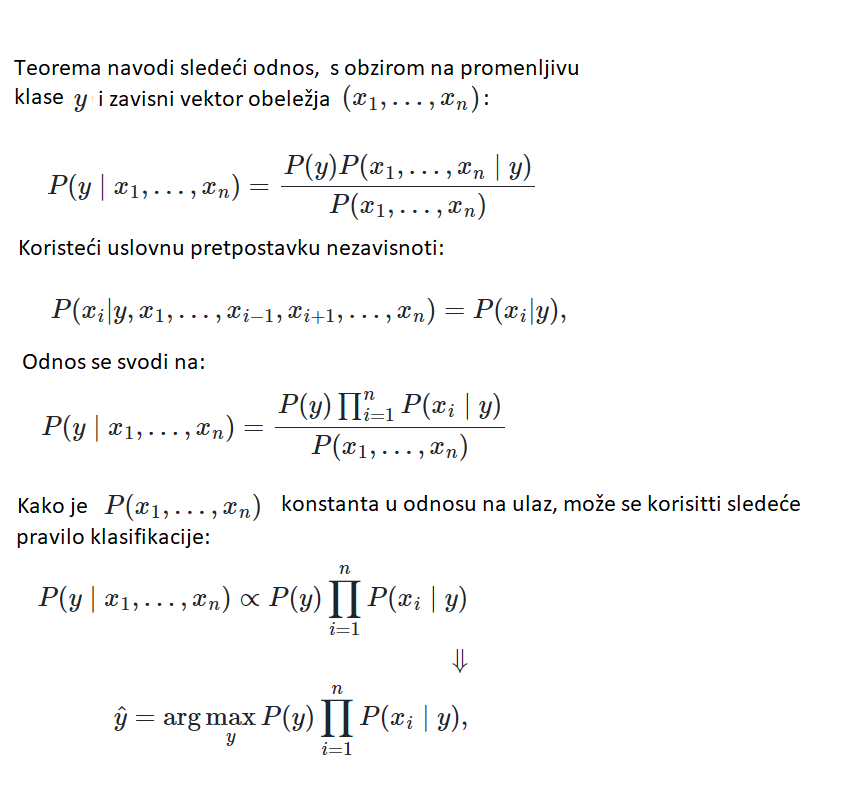

**Zaključak:** Računamo koliko je verovatna svaka klasa na osnovu osobina slike i biramo onu sa najvećom verovatnoćom.
Pretpostavljamo da osobine deluju nezavisno, što znatno pojednostavljuje računanje.

In [ ]:
# Import Gaussian Naive Bayes klasifikatora
from sklearn.naive_bayes import GaussianNB
# Inicijalizacija Naive Bayes klasifikatora
classifier = GaussianNB()

# Evaluacija modela korišćenjem Stratified K-Fold unakrsne validacije
scores = stratified_k_fold(classifier, df_train)

# Ispis tačnosti po svakom fold-u
print(scores)

# Računanje prosečne tačnosti klasifikacije
nb_acc = np.mean(scores, dtype=np.float64)
# Računanje standardne devijacije tačnosti
nb_std = np.std(scores, dtype=np.float64)

# Ispis prosečne tačnosti i standardne devijacije
print(nb_acc)
print(nb_std)


[0.59090909 0.59090909 0.46969697 0.55555556 0.55555556]
0.5525252525252526
0.044329511631296344


Gaussian Naive Bayes klasifikator ostvaruje lošije performanse u poređenju sa ostalim razmatranim modelima. Glavna pretpostavka ovog algoritma jeste da su ulazne promenljive međusobno nezavisne, što u ovom slučaju nije u potpunosti ispunjeno, s obzirom na to da su karakteristike listova često međusobno korelisane.

Iz tog razloga, primenjena je **PCA (Principal Component Analysis)** tehnika ekstrakcije obeležja, koja omogućava transformaciju skupa koreliranih promenljivih u novi skup **linearno nekorelisanih i ortogonalnih komponenti** (principal components). Ova transformacija smanjuje međuzavisnost obeležja i može poboljšati performanse klasifikatora koji se oslanjaju na pretpostavku nezavisnosti ulaznih podataka.

**Zaključak:** Naive Bayes ne voli kada su osobine međusobno povezane.
PCA ih „razdvaja“ u nove, nezavisnije komponente.

##### **Feature Extraction**

Algoritam **PCA (Principal Component Analysis)** konstruiše novi skup obeležja kao linearne kombinacije originalnih karakteristika. Matematički posmatrano, PCA vrši **linearnu transformaciju** kojom se originalni prostor obeležja preslikava u novi prostor definisan **glavnim komponentama** (*principal components*), koje su međusobno ortogonalne i linearno nekorelisane.

Kardinalnost izlaznog skupa obeležja, odnosno broj glavnih komponenti, može biti manja od broja ulaznih karakteristika. U mnogim slučajevima, najveći deo informacija sadržanih u ulaznim podacima može se reprezentovati manjim brojem komponenti, zbog čega se PCA često koristi kao metoda **redukcije dimenzionalnosti**.

Implementacija PCA algoritma u biblioteci *scikit-learn* zasniva se na **dekompoziciji singularnih vrednosti** (*Singular Value Decomposition – SVD*), metodi za izdvajanje sopstvenih vektora (*eigenvectors*), koji predstavljaju ortogonalne pravce najveće varijanse u prostoru ulaznih podataka.

Tehnike redukcije dimenzionalnosti koriste se kako bi se klasifikacioni modeli trenirali na manjem broju obeležja, čime se može unaprediti računska efikasnost modela i smanjiti rizik od pretreniranosti. Pored toga, ove tehnike mogu dovesti i do povećanja tačnosti modela, uklanjanjem redundantnih i visoko korelisanih karakteristika, dok se zadržavaju komponente sa najvećom varijansom, koje nose najviše informacija relevantnih za razdvajanje klasa.

PCA model u biblioteci *scikit-learn* inicijalizuje se izborom vrednosti parametara `n_components` i `svd_solver`. Vrednosti `mle` i `full` za ove parametre omogućavaju da se odredi **minimalan broj izlaznih komponenti** neophodan za očuvanje informacija iz ulaznog prostora, pri čemu se SVD dekompozicija rešava u potpunosti.


In [ ]:
# Import PCA algoritma iz sklearn biblioteke
from sklearn.decomposition import PCA

# Inicijalizacija PCA modela
# n_components='mle' automatski određuje optimalan broj komponenti
# svd_solver='full' koristi punu SVD dekompoziciju
pca = PCA(n_components='mle', svd_solver='full')

# Fitovanje PCA modela na trening skupu i transformacija podataka
df_train_pca = pca.fit_transform(df_train)

# Ispis broja obeležja pre i posle PCA transformacije
print("Number of descriptors before PCA: " + '{:1.0f}'.format(df_train.shape[1]))
print("Number of descriptors after PCA: " + '{:1.0f}'.format(df_train_pca.shape[1]))

Number of descriptors before PCA: 192
Number of descriptors after PCA: 191


In [ ]:
# Inicijalizacija Gaussian Naive Bayes klasifikatora
classifier = GaussianNB()

# Evaluacija Naive Bayes klasifikatora nad PCA-transformisanim podacima
scores = stratified_k_fold(classifier, pd.DataFrame(df_train_pca))

# Ispis tačnosti po svakom fold-u
print(scores)

# Računanje prosečne tačnosti klasifikacije
nb_pca_acc = np.mean(scores, dtype=np.float64)
# Računanje standardne devijacije tačnosti
nb_pca_std = np.std(scores, dtype=np.float64)

# Ispis prosečne tačnosti i standardne devijacije
print(nb_pca_acc)
print(nb_pca_std)

[0.94444444 0.94949495 0.96969697 0.98989899 0.93939394]
0.9585858585858587
0.01873458281918325


Obučavanjem Naive Bayes klasifikatora na ulaznim podacima koji su transformisani nakon PCA analize, rezultati su se značajno poboljšali, jer je sada pretpostavka o nezavisnosti karakteristika tačna.

### Uporedni rezultati

In [ ]:
# Kreiranje DataFrame-a sa uporednim rezultatima svih modela
models = pd.DataFrame({
    'Model': [
        'SGD Classifier',
        'Random Forest Classifier',
        'K Neighbors Classifier',
        'SVM Classifier',
        'SVM Parameter Tuning',
        'Naive Bayes',
        'Naive Bayes PCA'
    ],

    # Prosečna tačnost klasifikacije
    'Score': [
        sgd_acc,
        rndf_acc,
        knn_acc,
        svm_acc,
        grid_acc,
        nb_acc,
        nb_pca_acc
    ],

    # Standardna devijacija tačnosti (indikator varijanse)
    'Standard deviation': [   # (tipografski: deviation)
        sgd_std,
        rndf_std,
        knn_std,
        svm_std,
        grid_std,
        nb_std,
        nb_pca_std
    ]
})

# Sortiranje modela po prosečnoj tačnosti
models.sort_values(by='Score', ascending=True)


,Model,Score,Standard diviation
5,Naive Bayes,0.552525,0.044330
0,SGD Classifier,0.631313,0.065384
3,SVM Classifier,0.794949,0.024866
2,K Neighbors Classifier,0.858586,0.020202
4,SVM Paramater Tunning,0.947475,0.025273
6,Naive Bayes PCA,0.958586,0.018735
1,Random Forest Classifier,0.970707,0.009258


Rezultati pokazuju značajne razlike u performansama razmatranih klasifikacionih modela. Gaussian Naive Bayes treniran nad originalnim obeležjima ostvaruje najnižu tačnost, što je posledica kršenja pretpostavke nezavisnosti karakteristika. Linearni SGD model postiže ograničene performanse, dok SVM i KNN ostvaruju umereno do visoko dobre rezultate.

Optimizacija hiperparametara značajno unapređuje performanse SVM klasifikatora. Primena PCA transformacije pre treniranja Naive Bayes modela dovodi do drastičnog poboljšanja tačnosti, čime se potvrđuje značaj redukcije korelisanih obeležja.

Najbolje ukupne performanse postiže Random Forest klasifikator, sa najvišom prosečnom tačnošću i najmanjom varijansom, što ga čini najpouzdanijim modelom za dati zadatak.


####**MLP**

MLP (Multilayer Perceptron), poznat i kao **feedforward neuronska mreža** ili **deep feedforward network**, predstavlja matematički formalizam za aproksimaciju funkcija. U kontekstu zadatka klasifikacije, model aproksimira funkciju \( y = f^*(x) \), koja mapira ulazni vektor \( x \) u odgovarajuću klasu \( y \). Neuronska mreža definiše aproksimaciju oblika \( y = f(x; \theta) \), pri čemu se parametri \( \theta \) (težine i pomeraji) uče tokom procesa treniranja sa ciljem minimizacije greške aproksimacije.

Ovi modeli se nazivaju **feedforward**, jer informacija kroz mrežu teče jednosmerno – od ulaznog sloja, preko skrivenih slojeva, do izlaznog sloja. Ne postoje povratne veze u kojima se izlazne vrednosti vraćaju nazad u mrežu, što ih razlikuje od rekurentnih neuronskih mreža [7].

##### **Universal Approximation Theorem**

U matematičkoj teoriji veštačkih neuronskih mreža, **teorema o univerzalnoj aproksimaciji** odnosi se na aproksimacione sposobnosti neuronskih mreža u prostoru kontinuiranih funkcija [8]. Ova teorema tvrdi da neuronske mreže sa najmanje jednim skrivenim slojem i odgovarajućim nelinearnim aktivacionim funkcijama mogu aproksimirati širok spektar funkcija sa proizvoljnom tačnošću, pod uslovom da raspolažu dovoljnim brojem neurona.

Neuronske mreže mogu se posmatrati kao hijerarhijska kompozicija funkcija, gde se složene nelinearne relacije modeluju kroz više faza računanja. Ove faze se sastoje od linearnih transformacija, između kojih se primenjuju nelinearne aktivacione funkcije [9].

MLP se sastoji od **ulaznog sloja**, jednog ili više **skrivenih (hidden) slojeva** i **izlaznog sloja**. Neuroni svakog sloja povezani su sa neuronima narednog sloja, pri čemu se vrednosti neurona (aktivacije) iz jednog sloja koriste za izračunavanje aktivacija neurona u sledećem sloju. Na taj način mreža postepeno transformiše ulazne podatke u reprezentaciju pogodnu za donošenje konačne odluke o klasi.


##### **Backpropagation algoritam**

Težinski faktori neuronske mreže predstavljaju parametre koji se određuju tokom procesa treniranja optimizacijom **funkcije gubitka** (*loss function*). Funkcija gubitka kvantifikuje razliku između stvarnih izlaznih vrednosti i vrednosti koje mreža predviđa, čime se meri kvalitet aproksimacije koju mreža ostvaruje.

Proces treniranja neuronske mreže može se posmatrati kao problem **minimizacije funkcije gubitka**, odnosno pronalaženja optimalnih vrednosti parametara koje dovode do tačnijih predikcija aproksimirane funkcije. Ažuriranje parametara vrši se u smeru **negativnog gradijenta** funkcije gubitka, jer taj smer vodi ka njenom smanjenju.

Izračunavanje gradijenata funkcije gubitka u odnosu na težinske faktore vrši se primenom algoritma **backpropagation** (*unazadna propagacija*). Ovaj algoritam omogućava efikasno računanje parcijalnih izvoda korišćenjem lančanog pravila, pri čemu se greška sa izlaznog sloja propagira unazad kroz mrežu, sve do ulaznog sloja. Na taj način se omogućava sistematsko i efikasno ažuriranje težina u svim slojevima neuronske mreže.


**Sumarno:** Backpropagation računa koliko je svaka težina „krivac“ za grešku i zatim je ispravlja u pravom smeru.

In [ ]:
# Import Keras biblioteke i neophodnih modula za definisanje neuronske mreže
import keras
from keras.models import Sequential
from keras.layers import Dense
from keras.activations import relu, softmax

# Provera dimenzija ulaznih i izlaznih podataka
print(df_train_copy.shape)   # Trening skup (broj instanci, broj feature-a)
print(df_test_copy.shape)    # Test skup (broj instanci, broj feature-a)
print(labels_copy.shape)     # Labele (ciljna promenljiva)

(990, 192)
(594, 192)
(990,)


In [ ]:
# Import StandardScaler-a za standardizaciju podataka
from sklearn.preprocessing import StandardScaler

# Inicijalizacija skalera
sc = StandardScaler()
# Fitovanje i transformacija trening skupa
sc.fit_transform(df_train_copy)

array([[-0.48661074, -0.13135701, -0.33095592, ..., -0.39487147,
        -0.65214311,  0.26239707],
       [-0.58560191, -0.73488047, -0.02856115, ..., -0.49497401,
         2.18166976,  0.13364087],
       [-0.58560191, -0.48340807, -0.48219201, ..., -0.52001246,
         0.83564129, -0.72463124],
       ...,
       [-0.78358426, -0.63430181, -1.23821765, ...,  0.1807566 ,
        -0.65214311, -0.76756462],
       [-0.88257543, -0.73488047,  0.5762671 , ..., -0.52001246,
        -0.51045972, -0.72463124],
       [ 0.30542003, -0.23196142, -0.02856115, ...,  0.08065405,
         1.18988604,  0.13364087]])

Pored skaliranja ulaznih podataka, neophodno je izvršiti i kodiranje kategoričkih labela sa kojima neuronska mreža radi. Postoji više pristupa kodiranju kategorija, među kojima su najčešće korišćeni:

- **Celobrojno kodiranje (Label Encoding)** – svaka klasa se preslikava u jedinstvenu celobrojnu vrednost  
- **One-Hot Encoding** – svaka klasa se predstavlja binarnim vektorom  
- **Naučene reprezentacije** – kategorije se mapiraju u kontinuirani prostor tokom treniranja modela  

U ovom radu korišćen je **One-Hot Encoding**, primenom klase `OneHotEncoder` iz biblioteke *scikit-learn*, budući da je ovaj pristup najpogodniji za višeklasne klasifikacione zadatke sa neuronskim mrežama i softmax izlaznim slojem.


In [ ]:
# Import OneHotEncoder-a za kodiranje kategorijskih labela
from sklearn.preprocessing import OneHotEncoder
# Inicijalizacija One-Hot enkodera
ohe = OneHotEncoder()

# Pretvaranje labela u DataFrame (radi kompatibilnosti)
labels_copy = pd.DataFrame(labels_copy)

# One-Hot Encoding labela
labels_one_hot = ohe.fit_transform(
    labels_copy.values.reshape(-1, 1)
).toarray()

# Provera dimenzija one-hot kodiranih labela
print(labels_one_hot.shape)

# Prikaz one-hot vektora za prvu instancu
print(labels_one_hot[0])

(990, 99)
[0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0.]


Kao i u slučaju obučavanja prethodnih modela, izvršena je **stratifikovana podela podataka** na skup za treniranje i validaciju, kao i na test skup koji se koristi nakon završene faze treniranja i validacije.

Za razliku od prethodnih modela, kod MLP modela **nije primenjena unakrsna validacija**, već je evaluacija izvršena na izdvojenom test skupu, zbog veće računske složenosti i vremena potrebnog za treniranje neuronskih mreža.

In [ ]:
# Import metoda za podelu podataka
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit

# Stratifikovana podela: izdvajamo test skup (10%) tako da se očuva raspodela klasa
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.1, random_state=42)

# Dobijanje indeksa trening i test instanci
train_index, test_index = next(iter(sss.split(df_train_copy, labels_one_hot)))

# Formiranje trening i test skupa
X_train_nn, X_test_nn = df_train_copy.iloc[train_index, :], df_train_copy.iloc[test_index, :]
y_train_nn, y_test_nn = labels_one_hot[train_index], labels_one_hot[test_index]

# Napomena:
# Ponovna STRATIFIKOVANA podela train -> val nije trivijalna kada su labele one-hot kodirane,
# jer StratifiedShuffleSplit očekuje 1D vektor klasa (npr. celobrojne labele), a ne one-hot matricu.

# Podela trening skupa na train i validation (10% od train skupa)
X_train_nn, X_val_nn, y_train_nn, y_val_nn = train_test_split(
    X_train_nn, y_train_nn, test_size=0.10, random_state=42
)

# Provera dimenzija
print("x_train dim: ", X_train_nn.shape)
print("x_test dim:   ", X_test_nn.shape)
print("x_val dim:   ", X_val_nn.shape)
print()

x_train dim:  (801, 192)
x_test dim:    (99, 192)
x_val dim:    (90, 192)



Aktivacione funkcije primenjuju se na izlazima skrivenih slojeva i omogućavaju uvođenje nelinearnosti u model.

Na slici su prikazane najčešće korišćene aktivacione funkcije.

 Sigmoid i tanh funkcije uvode nelinearnost, ali pate od problema zasićenja i nestajućih gradijenata.

 ReLU funkcija, definisana kao \( g(z) = \max(0, z) \), omogućava efikasnije učenje dubokih mreža zbog jednostavne forme i boljeg protoka gradijenta.

 Leaky ReLU predstavlja varijantu ReLU funkcije koja ublažava problem „mrtvih neurona“ dozvoljavajući mali negativni nagib.

 U ovom radu korišćena je **ReLU (Rectified Linear Unit)** aktivaciona funkcija.


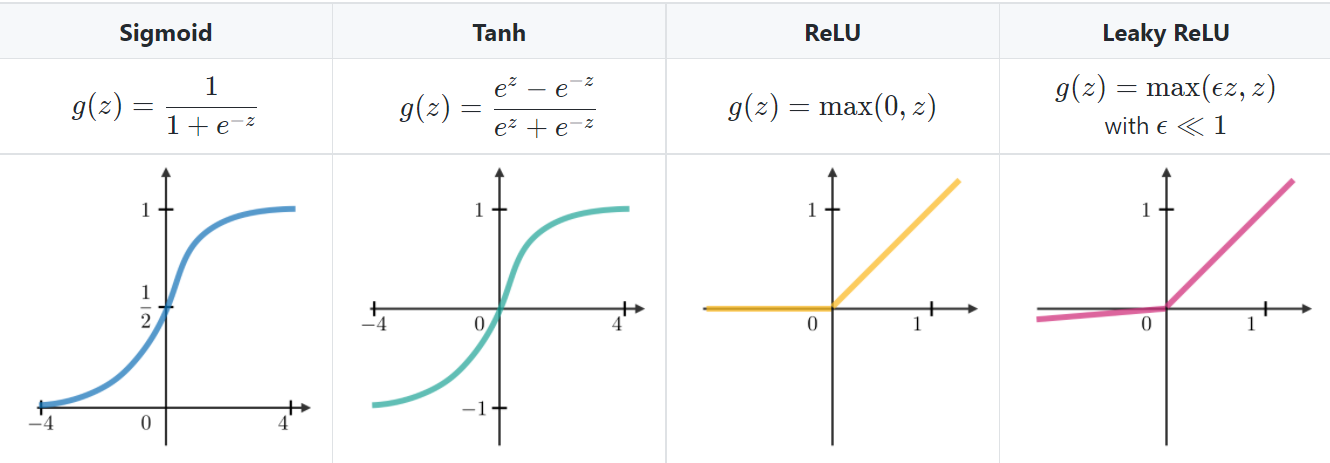

Svi slojevi u modelu su **Dense (potpuno povezani) slojevi** sa unapred definisanim brojem neurona. Poslednji sloj koristi **softmax aktivacionu funkciju**, koja transformiše izlazni vektor od \(K\) realnih vrednosti u vektor verovatnoća čija je suma jednaka 1.

Na ovaj način, softmax funkcija dodeljuje verovatnoću svakoj od klasa u multi-class problemu, dok se kao konačna predikcija uzima klasa sa najvećom dodeljenom verovatnoćom.


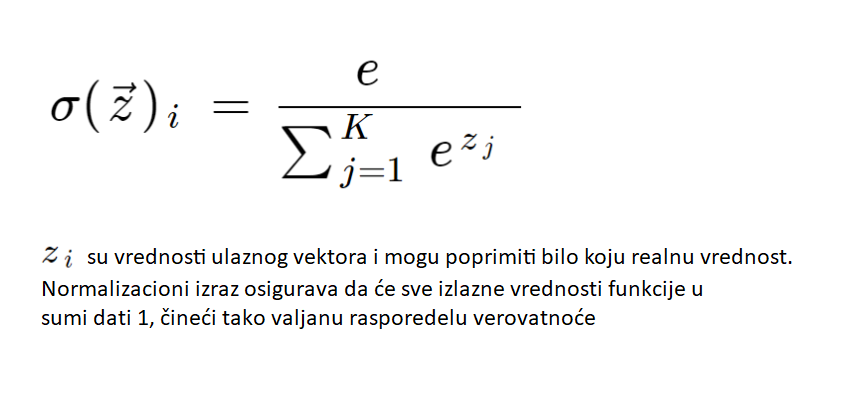

In [ ]:
# Import neophodnih Keras modula
import keras
from keras.models import Sequential
from keras.layers import Dense
from keras.activations import relu, softmax

# Definisanje MLP modela kao sekvencijalnog niza slojeva
model = Sequential()

# Ulazni sloj + prvi skriveni sloj
# input_dim=192 odgovara broju ulaznih feature-a
model.add(Dense(256, input_dim=192, activation='relu'))

# Skriveni slojevi sa ReLU aktivacionom funkcijom
model.add(Dense(512, activation='relu'))
model.add(Dense(600, activation='relu'))
model.add(Dense(1024, activation='relu'))
model.add(Dense(1600, activation='relu'))

# Izlazni sloj
# 99 neurona odgovara broju klasa
# softmax aktivaciona funkcija proizvodi raspodelu verovatnoće po klasama
model.add(Dense(99, activation='softmax'))

**Categorical Cross-Entropy** funkcija gubitka, poznata i kao **Softmax loss**, koristi se u zadacima višeklasne klasifikacije u kombinaciji sa softmax aktivacionom funkcijom u izlaznom sloju neuronske mreže.

 U problemu sa C klasa formula je sledeća [10]:

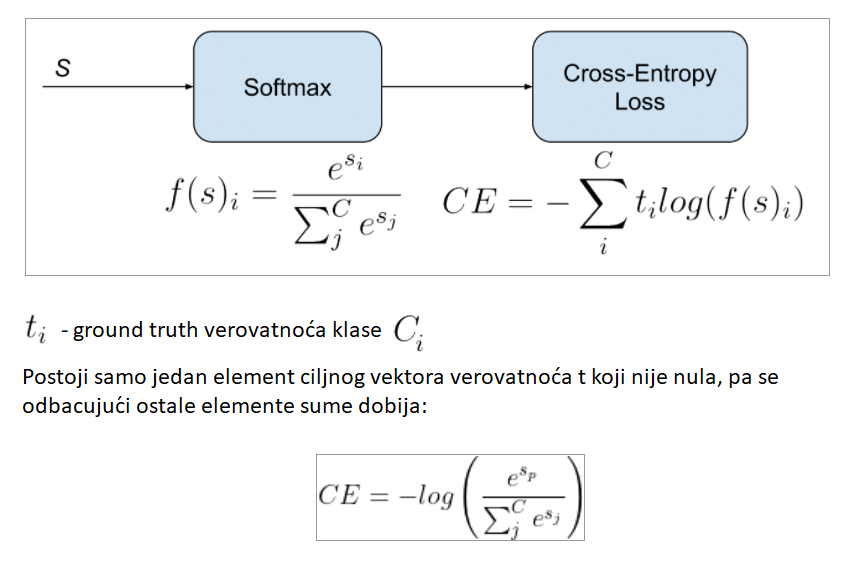

##### **Optimizacioni algoritam**

Prilikom kompajliranja neuronske mreže definišu se parametri `loss`, `optimizer` i `metrics`, koji redom predstavljaju funkciju gubitka koja se minimizuje tokom treniranja, algoritam optimizacije koji se koristi za ažuriranje težinskih faktora i metrike pomoću kojih se prate performanse modela.

Neki od najčešće korišćenih optimizacionih algoritama su:
- **SGD (Stochastic Gradient Descent)**
- **RMSprop (Root Mean Square Propagation)**
- **Adam (Adaptive Moment Estimation)**

Algoritam optimizacije utiče na način i brzinu učenja modela, odnosno na stopu učenja koja se primenjuje pri svakom ažuriranju parametara. U ovom radu korišćen je **Adam optimizator**, koji kombinuje prednosti dva prethodna pristupa.

Algoritam **AdaGrad** prilagođava stopu učenja svakom parametru pojedinačno, što je posebno pogodno za probleme sa retkim gradijentima. Sa druge strane, **RMSprop** koristi eksponencijalni pokretni prosek kvadrata gradijenata kako bi prilagodio stopu učenja u skladu sa nedavnim promenama gradijenata.

Adam optimizator objedinjuje ove pristupe koristeći i **prvi momenat gradijenta** (srednju vrednost) i **drugi momenat gradijenta** (necentriranu varijansu). Na taj način izračunava eksponencijalne pokretne proseke gradijenta i kvadrata gradijenta, dok parametri \( \beta_1 \) i \( \beta_2 \) kontrolišu brzinu opadanja ovih proseka, omogućavajući stabilno i efikasno treniranje neuronske mreže [11].


In [ ]:
#Model je kompajliran korišćenjem categorical cross-entropy funkcije gubitka, koja je standardni izbor za višeklasne klasifikacione zadatke
# u kombinaciji sa softmax izlaznim slojem i one-hot kodiranim labelama.
# Za optimizaciju težinskih faktora korišćen je Adam optimizator, koji omogućava stabilno i efikasno treniranje
# Kao metrika uspešnosti praćen jeaccuracy, koja predstavlja odnos broja tačno klasifikovanih instanci i ukupnog broja instanci.

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

Prilikom obučavanja modela, definiše se broj epoha, pri čemu epoha predstavlja prolazak preko celokupnog skupa trening podataka. Epoha se sastoji iz iteracija, gde broj iteracija zavisi od veličine batch-a (broj uzoraka po ažuriranju gradijenta). Nakon svake iteracije i prolaska kroz određeni broj podataka (određen veličinom batch-a), na osnovu sračunate funkcije gubitka se vrše podešavanja parametara i zatim uz pomoć validacionih podataka računa tačnost modela.


In [ ]:
# Import callback-a za čuvanje najboljeg modela tokom treniranja
from keras.callbacks import ModelCheckpoint

# Definisanje callback-a:
# model će biti sačuvan samo ako se poboljša performansa na validacionom skupu
checkpointer = ModelCheckpoint(filepath='nn_model.hdf5', verbose=1, save_best_only=True)

# Treniranje MLP modela
history = model.fit( X_train_nn, y_train_nn, epochs=100, validation_data=(X_val_nn, y_val_nn), callbacks=[checkpointer])

Epoch 1/100
26/26 [==============================] - 2s 54ms/step - loss: 4.5872 - accuracy: 0.0224 - val_loss: 4.2756 - val_accuracy: 0.0222

Epoch 00001: val_loss improved from inf to 4.27558, saving model to nn_model.hdf5
Epoch 2/100
26/26 [==============================] - 1s 36ms/step - loss: 3.9300 - accuracy: 0.0604 - val_loss: 3.1231 - val_accuracy: 0.1111

Epoch 00002: val_loss improved from 4.27558 to 3.12313, saving model to nn_model.hdf5
Epoch 3/100
26/26 [==============================] - 1s 35ms/step - loss: 2.8856 - accuracy: 0.1470 - val_loss: 3.0782 - val_accuracy: 0.0667

Epoch 00003: val_loss improved from 3.12313 to 3.07816, saving model to nn_model.hdf5
Epoch 4/100
26/26 [==============================] - 1s 37ms/step - loss: 2.6058 - accuracy: 0.2255 - val_loss: 2.2241 - val_accuracy: 0.3222

Epoch 00004: val_loss improved from 3.07816 to 2.22411, saving model to nn_model.hdf5
Epoch 5/100
26/26 [==============================] - 1s 36ms/step - loss: 1.8969 - accur

Definisane su metode koje za prosleđen model i istoriju obučavanja modela ispisuju tačnost modela i grafike koji pokazuju kretanje vrednosti funkcije gubitka i tačnosti klasifikacije modela kroz epohe. Na osnovu ovih grafika analizirana je performansa modela i dalji koraci njegovog poboljšanja.

In [ ]:
def print_scores(X_train_nn, y_train_nn, X_test_nn, y_test_nn, model):
    # Evaluacija modela na trening skupu
    score = model.evaluate(X_train_nn, y_train_nn, verbose=1)
    accuracy = 100 * score[1]
    print('Test accuracy on train data is %.4f%%' % accuracy)

    # Evaluacija modela na test skupu
    score = model.evaluate(X_test_nn, y_test_nn, verbose=1)
    accuracy = 100 * score[1]
    print('Test accuracy on test data is %.4f%%' % accuracy)

In [ ]:
import matplotlib.pyplot as plt

def print_and_plot_history(history):
    # Ispis maksimalne tačnosti i minimalnog gubitka na validacionom skupu
    print('val_acc: ', max(history.history['val_accuracy']))
    print('val_loss: ', min(history.history['val_loss']))

    # Ispis maksimalne tačnosti i minimalnog gubitka na trening skupu
    print('train_acc: ', max(history.history['accuracy']))
    print('train_loss: ', min(history.history['loss']))

    # Odnos minimalnog trening i validacionog gubitka
    print("train/val loss ratio: ",
          min(history.history['loss']) / min(history.history['val_loss']))

    # Grafikon funkcije gubitka (logaritamska skala)
    plt.semilogy(history.history['loss'])
    plt.semilogy(history.history['val_loss'])
    plt.title('model loss')
    plt.ylabel('loss')
    plt.xlabel('epoch')
    plt.legend(['train', 'validation'], loc='upper left')
    plt.show()

    # Grafikon tačnosti klasifikacije
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title('model accuracy')
    plt.ylabel('accuracy')
    plt.xlabel('epoch')
    plt.legend(['train', 'validation'], loc='upper left')
    plt.show()

26/26 [==============================] - 0s 7ms/step - loss: 7.8195e-05 - accuracy: 1.0000
Test accuracy on train data is 100.0000%
4/4 [==============================] - 0s 7ms/step - loss: 0.3937 - accuracy: 0.8889
Test accuracy on test data is 88.8889%
val_acc:  0.8222222328186035
val_loss:  0.7214375138282776
train_acc:  1.0
train_loss:  7.990116864675656e-05
train/val loss ratio:  0.0001107527223290128


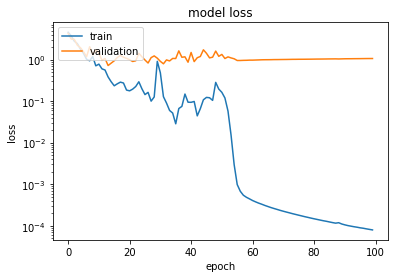

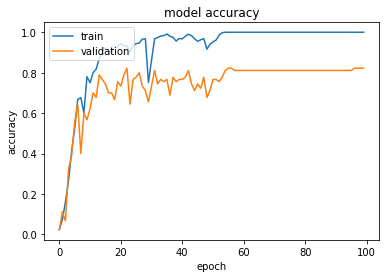

In [ ]:
print_scores(X_train_nn, y_train_nn, X_test_nn, y_test_nn, model)
print_and_plot_history(history)

Na osnovu prikazanih grafika i numeričkih rezultata može se uočiti da MLP model veoma brzo postiže visoku tačnost na trening skupu, dostižući maksimalnu vrednost od 1.0, uz gotovo zanemarljivu vrednost funkcije gubitka. Sa druge strane, tačnost na validacionom skupu stabilizuje se na oko 0.82, dok validacioni gubitak ostaje značajno viši u odnosu na trening gubitak.

Velika razlika između trening i validacionih rezultata, kao i izrazito nizak odnos trening i validacionog gubitka, ukazuju na pojavu **pretreniranosti (overfitting)**. Model veoma dobro uči trening podatke, ali slabije generalizuje na neviđene primere.

Uprkos tome, ostvarena tačnost na test skupu od približno **88.9%** pokazuje da model i dalje postiže relativno dobre performanse, ali bi dodatne tehnike regularizacije (npr. dropout, smanjenje složenosti mreže ili ranije zaustavljanje treniranja) mogle doprineti boljoj generalizaciji.


Drugi mogući uzrok jeste **premala vrednost parametra `batch_size`**. Ažuriranje težinskih faktora na osnovu malog broja instanci može dovesti do nestabilnog učenja, posebno u prisustvu šuma ili potencijalno pogrešno označenih podataka. Dodatno, s obzirom na to da dataset sadrži 99 klasa, mali `batch_size` može rezultovati time da u pojedinim batch-evima bude zastupljen veoma mali broj klasa, što negativno utiče na proces učenja.

Iz tog razloga, u nastavku je arhitektura modela pojednostavljena, a podrazumevana vrednost parametra `batch_size` od 32 zamenjena je vrednošću 192, kako bi se obezbedila stabilnija optimizacija i bolja generalizacija modela.


In [ ]:
# Definisanje uprošćene MLP arhitekture
modelv2 = Sequential()

# Ulazni sloj + prvi skriveni sloj
modelv2.add(Dense(256, input_dim=192, activation='relu'))

# Skriveni slojevi sa manjim ukupnim brojem parametara
modelv2.add(Dense(512, activation='relu'))
modelv2.add(Dense(600, activation='relu'))

# Izlazni sloj sa softmax aktivacionom funkcijom
modelv2.add(Dense(99, activation='softmax'))

In [ ]:
modelv2.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
checkpointer=ModelCheckpoint(filepath='nn_modelv2.hdf5',verbose=1,save_best_only=True)
historyv2 = modelv2.fit(X_train_nn, y_train_nn, epochs=100, batch_size=192,
                    validation_data=(X_val_nn, y_val_nn),callbacks=[checkpointer])

Epoch 1/100
5/5 [==============================] - 1s 121ms/step - loss: 4.5921 - accuracy: 0.0334 - val_loss: 4.5752 - val_accuracy: 0.1333

Epoch 00001: val_loss improved from inf to 4.57518, saving model to nn_modelv2.hdf5
Epoch 2/100
5/5 [==============================] - 0s 20ms/step - loss: 4.5623 - accuracy: 0.2071 - val_loss: 4.5419 - val_accuracy: 0.1111

Epoch 00002: val_loss improved from 4.57518 to 4.54191, saving model to nn_modelv2.hdf5
Epoch 3/100
5/5 [==============================] - 0s 20ms/step - loss: 4.5107 - accuracy: 0.2080 - val_loss: 4.4808 - val_accuracy: 0.1222

Epoch 00003: val_loss improved from 4.54191 to 4.48082, saving model to nn_modelv2.hdf5
Epoch 4/100
5/5 [==============================] - 0s 19ms/step - loss: 4.4036 - accuracy: 0.2028 - val_loss: 4.3814 - val_accuracy: 0.0778

Epoch 00004: val_loss improved from 4.48082 to 4.38139, saving model to nn_modelv2.hdf5
Epoch 5/100
5/5 [==============================] - 0s 21ms/step - loss: 4.2193 - accura

Uprošćeni MLP model (modelv2) kompajliran je korišćenjem **categorical cross-entropy** funkcije gubitka i **Adam** optimizacionog algoritma. Kao metrika uspešnosti praćena je tačnost klasifikacije.

Model je treniran tokom 100 epoha sa povećanom vrednošću parametra `batch_size = 192`, čime se obezbeđuje stabilnije ažuriranje parametara i bolja zastupljenost klasa unutar svakog batch-a. Tokom treniranja korišćen je **ModelCheckpoint** callback, koji omogućava čuvanje modela sa najboljim performansama na validacionom skupu.

Ovakav pristup omogućava smanjenje pretreniranosti i poboljšanje sposobnosti generalizacije modela u odnosu na prethodnu, složeniju arhitekturu.


26/26 [==============================] - 0s 3ms/step - loss: 0.0108 - accuracy: 1.0000
Test accuracy on train data is 100.0000%
4/4 [==============================] - 0s 4ms/step - loss: 0.4118 - accuracy: 0.8788
Test accuracy on test data is 87.8788%
val_acc:  0.8999999761581421
val_loss:  0.37919121980667114
train_acc:  1.0
train_loss:  0.011210842058062553
train/val loss ratio:  0.02956514147078181


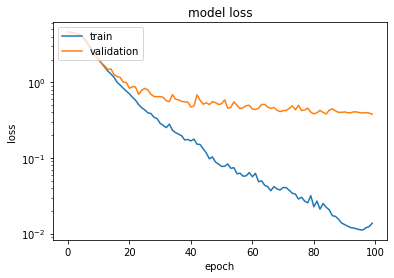

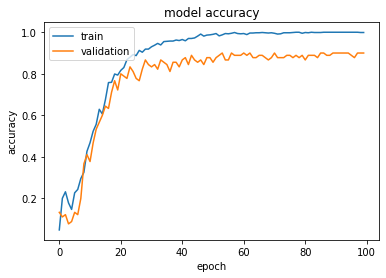

In [ ]:
print_scores(X_train_nn, y_train_nn, X_test_nn, y_test_nn, modelv2)
print_and_plot_history(historyv2)

Nakon pojednostavljivanja arhitekture i povećanja vrednosti parametra `batch_size`, model pokazuje stabilnije ponašanje tokom faze treniranja. Validaciona tačnost povećana je na oko 0.90, dok je validacioni gubitak značajno smanjen, što ukazuje na unapređenje procesa učenja u odnosu na prethodnu verziju modela.

Ipak, i dalje se uočava razlika između trening i validacionih krivih. Kriva funkcije gubitka na trening skupu opada znatno brže u odnosu na validacionu krivu, što ukazuje da naučeni parametri ne obezbeđuju potpunu generalizaciju na podatke koji nisu korišćeni tokom treniranja. Ovakvo ponašanje predstavlja pojavu **pretreniranosti (overfitting)**, koja je u ovom slučaju očekivana s obzirom na relativno mali skup podataka u odnosu na složenost modela.

Jedan od načina za ublažavanje overfitting-a jeste treniranje više modela različitih arhitektura i kombinovanje njihovih predikcija kroz ansambl pristup. Alternativno, može se primeniti i **Dropout** tehnika regularizacije, koja tokom treniranja nasumično isključuje određeni procenat izlaza neurona, čime se uvodi kontrolisani šum u proces učenja.

Primenom Dropout sloja smanjuje se zavisnost modela od pojedinačnih neurona i podstiče robusnije učenje, što može doprineti boljoj generalizaciji i stabilnijim performansama na neviđenim podacima.


In [ ]:
from keras.layers import Dropout
# Definisanje MLP modela sa Dropout regularizacijom
modelv3 = Sequential()

# Ulazni sloj + prvi skriveni sloj
modelv3.add(Dense(256, input_dim=192, activation='relu'))
modelv3.add(Dropout(0.1))   # Dropout sloj sa verovatnoćom isključivanja od 10%

# Drugi skriveni sloj
modelv3.add(Dense(512, activation='relu'))
modelv3.add(Dropout(0.1))   # Dropout radi smanjenja pretreniranosti

# Treći skriveni sloj
modelv3.add(Dense(600, activation='relu'))

# Izlazni sloj
modelv3.add(Dense(99, activation='softmax'))

In [ ]:
modelv3.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [ ]:
checkpointer=ModelCheckpoint(filepath='nn_modelv3.hdf5',verbose=1,save_best_only=True)
historyv3 = modelv3.fit(X_train_nn, y_train_nn, epochs=100, batch_size=192,
                    validation_data=(X_val_nn, y_val_nn),callbacks=[checkpointer])

Epoch 1/100
5/5 [==============================] - 1s 137ms/step - loss: 4.5923 - accuracy: 0.0108 - val_loss: 4.5755 - val_accuracy: 0.0444

Epoch 00001: val_loss improved from inf to 4.57551, saving model to nn_modelv3.hdf5
Epoch 2/100
5/5 [==============================] - 0s 22ms/step - loss: 4.5643 - accuracy: 0.0834 - val_loss: 4.5470 - val_accuracy: 0.0444

Epoch 00002: val_loss improved from 4.57551 to 4.54697, saving model to nn_modelv3.hdf5
Epoch 3/100
5/5 [==============================] - 0s 21ms/step - loss: 4.5124 - accuracy: 0.1046 - val_loss: 4.4857 - val_accuracy: 0.0333

Epoch 00003: val_loss improved from 4.54697 to 4.48568, saving model to nn_modelv3.hdf5
Epoch 4/100
5/5 [==============================] - 0s 24ms/step - loss: 4.4246 - accuracy: 0.0873 - val_loss: 4.3825 - val_accuracy: 0.0667

Epoch 00004: val_loss improved from 4.48568 to 4.38254, saving model to nn_modelv3.hdf5
Epoch 5/100
5/5 [==============================] - 0s 22ms/step - loss: 4.2606 - accura

MLP model sa Dropout regularizacijom (modelv3) treniran je tokom 100 epoha sa veličinom batch-a od 192, pri čemu su korišćeni trening i validacioni skup. Tokom procesa treniranja primenjen je **ModelCheckpoint** callback, koji omogućava čuvanje modela sa najboljim performansama na validacionom skupu.

Uvođenjem Dropout slojeva očekuje se smanjenje pretreniranosti u odnosu na prethodnu verziju modela, budući da se tokom treniranja nasumično isključuju pojedini neuroni. Time se podstiče učenje robusnijih i opštijih reprezentacija, što može doprineti poboljšanoj generalizaciji modela na neviđene podatke.


26/26 [==============================] - 0s 3ms/step - loss: 0.0181 - accuracy: 0.9975
Test accuracy on train data is 99.7503%
4/4 [==============================] - 0s 4ms/step - loss: 0.2817 - accuracy: 0.9091
Test accuracy on test data is 90.9091%
val_acc:  0.9444444179534912
val_loss:  0.19267819821834564
train_acc:  0.9975031018257141
train_loss:  0.03442761301994324
train/val loss ratio:  0.1786793385981811


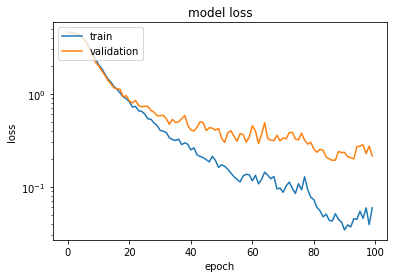

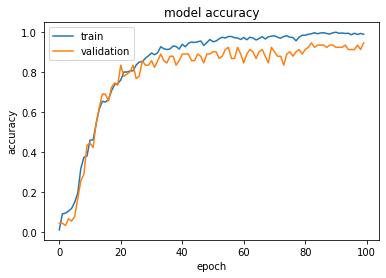

In [ ]:
print_scores(X_train_nn, y_train_nn, X_test_nn, y_test_nn, modelv3)
print_and_plot_history(historyv3)

Na osnovu prikazanih krivih učenja i numeričkih rezultata, može se zaključiti da modelv3 ostvaruje stabilnije treniranje i bolju generalizaciju u odnosu na prethodne verzije MLP modela. Za razliku od modela v1 i v2, kod kojih je uočena izraženija razlika između trening i validacionih metrika, kod modelv3 trening i validacione krive su znatno bliže, što ukazuje na uspešnije ublažavanje pretreniranosti.

Postignuta je visoka validaciona tačnost (val_acc ≈ 0.94) uz značajno niži validacioni gubitak (val_loss ≈ 0.19). Takođe, test tačnost iznosi približno **90.9%**, što predstavlja najbolji rezultat među razmatranim MLP varijantama. Vrednosti trening tačnosti (≈ 0.998) i trening gubitka (≈ 0.034) ukazuju da model uspešno uči obrasce iz trening podataka, ali bez ekstremnog „memorisanju“ kao kod prvog modela, što potvrđuje efekat regularizacije.

Najbolje performanse modelv3 mogu se pripisati kombinaciji sledećih izmena: povećanju `batch_size` parametra, redukciji složenosti mreže (manji broj slojeva) i primeni **Dropout** mehanizma kao tehnike regularizacije.


Uspešnost klasifikacije razvijenih neuronskih modela trebalo bi proceniti robusnijim metodama, kao što je unakrsna validacija. Ipak, na izdvojenom test skupu najbolje se pokazao treći model (modelv3), koji kombinuje povećani `batch_size`, redukovanu arhitekturu i Dropout regularizaciju.



### **Zaključak**

Zadatak klasifikacije biljaka na osnovu oblika lista rešen je obučavanjem šest modela mašinskog učenja: **SGD**, **Random Forest**, **K Neighbors**, **SVM**, **Naive Bayes** i **MLP**. Svi modeli trenirani su nad unapred ekstraktovanim karakteristikama listova. Procena uspešnosti i stabilnosti modela izvršena je primenom **stratifikovane unakrsne validacije**, čime je omogućena analiza bias–variance kompromisa.

Performanse pojedinih modela dodatno su unapređene odgovarajućim tehnikama: **SVM** model optimizovan je primenom **Grid Search** metode za podešavanje hiperparametara, dok je **Naive Bayes** klasifikator značajno unapređen primenom **PCA analize** za redukciju korelisanih obeležja. Kod **MLP** modela, arhitektura i parametri treniranja prilagođavani su na osnovu analize krivih gubitka i tačnosti tokom epoha.

Najbolje performanse ostvarili su **Random Forest** klasifikator (97.88 ± 0.004), **Naive Bayes** nakon PCA transformacije (95.86 ± 0.019) i **SVM** sa optimizovanim hiperparametrima (94.74 ± 0.025), čime su se ovi modeli pokazali kao najpouzdaniji za dati višeklasni problem.

Dalja unapređenja mogu se postići dodatnom optimizacijom parametara pojedinačnih modela (npr. izbor parametra *k* kod KNN algoritma), razvojem ansambala različitih MLP arhitektura, kao i treniranjem modela nad većim skupom podataka, uključujući tehnike **augmentacije podataka**. Dodatno, analiza **konfuzione matrice** može pomoći u identifikaciji klasa koje se najčešće pogrešno klasifikuju, što može poslužiti kao osnova za razvoj novih karakteristika ili unapređenje postojećih modela.


###**Literatura**


[1] Silva, P.F.B. (2013). *Development of a System for
Automatic Plant Species Recognition* (Master's thesis, Faculty of Science of University Porto, Porto, Portugal). Retrieved from https://repositorio-aberto.up.pt/handle/10216/67734

[2] Mallah, C., Cope, J., & Orwell, J. (2013). Plant leaf classification using probabilistic integration of shape, texture and margin features. *Signal Processing, Pattern Recognition and Applications*, 5(1)

[3] scikit-learn. (n.d.). Visualizing cross-validation behavior in scikit-learn. https://scikit-learn.org/stable/auto_examples/model_selection/plot_cv_indices.html#

[4] Singh, S. (2021, May 21). Understanding the Bias-Variance Tradeoff. Retrieved from https://towardsdatascience.com/understanding-the-bias-variance-tradeoff-165e6942b229

[5] Ćulibrk, D. (2012). *Otkrivanje znanja iz podataka: Odabrana poglavlja*. Fort Lauderdale, USA: CreateSpace Independent Publishing Platform.

[6] scikit-learn. (n.d.). Naive Bayes. https://scikit-learn.org/stable/modules/naive_bayes.html

[7] Goodfellow, I. & Bengio Y. & CourvilleClark A. (2016).*Deep Learning*. An MIT Press book. https://doi.https://www.deeplearningbook.org/

[8] Hornik, K., Stinchcombe, M., & White, H. (1989). *Multilayer feedforward networks are universal approximators. Neural networks*, 2(5), 359-366.

[9] Stanford University School of Engineering. (2017, August 11). *Lecture 4|Introduction to Neural Networks* [Video]. https://www.youtube.com/watch?v=d14TUNcbn1k

[10] Gomez, R. (2018, May 23). *Understanding Categorical Cross-Entropy Loss, Binary Cross-Entropy Loss, Softmax Loss, Logistic Loss, Focal Loss and all those confusing names*. Raúl Gómez blog. https://gombru.github.io/2018/05/23/cross_entropy_loss/

[11] Singh, S. (2021, May 21). Adam — latest trends in deep learning optimization. Retrieved from https://towardsdatascience.com/adam-latest-trends-in-deep-learning-optimization-6be9a291375c